In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
sns.set_style()

In [2]:
df = pd.read_csv('./data/state_melt.csv')

In [3]:
df['Registrations'] = df['Registrations'].str.replace(',','').astype(int)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20160 entries, 0 to 20159
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   YEAR           20160 non-null  int64 
 1   STATE          20160 non-null  object
 2   Fuel_Type      20160 non-null  object
 3   Registrations  20160 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 630.1+ KB


In [5]:
df['Registrations'] = pd.to_numeric(df['Registrations'], errors='coerce')

In [6]:
df.dropna(subset=['Registrations'], inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20160 entries, 0 to 20159
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   YEAR           20160 non-null  int64 
 1   STATE          20160 non-null  object
 2   Fuel_Type      20160 non-null  object
 3   Registrations  20160 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 630.1+ KB


In [8]:
def aggregate_fuel_type_specific(fuel_type):
    fuel_type_upper = str(fuel_type).upper()
    if fuel_type_upper in ['PETROL', 'PETROL/CNG', 'PETROL/HYBRID', 'PETROL/LPG', 'PETROL/ETHANOL', 'PETROL/METHANOL']:
        return 'Petrol'
    elif fuel_type_upper in ['DIESEL', 'DIESEL/HYBRID', 'DUAL DIESEL/CNG']:
        return 'Diesel'
    elif fuel_type_upper in ['ELECTRIC(BOV)', 'PURE EV', 'FUEL CELL HYDROGEN']:
        return 'Electric (EV)'
    elif fuel_type_upper in ['PLUG-IN HYBRID EV', 'STRONG HYBRID EV']:
        return 'Hybrid EV'
    elif fuel_type_upper in ['CNG ONLY', 'LPG ONLY']:
        return 'CNG/LPG'
    else:
        return 'Other/Unknown'

df['Aggregated_Category_Specific'] = df['Fuel_Type'].apply(aggregate_fuel_type_specific)

In [9]:
df.head()

,YEAR,STATE,Fuel_Type,Registrations,Aggregated_Category_Specific
0,2002,ANDAMAN & NICOBAR ISLAND,CNG ONLY,0,CNG/LPG
1,2002,ANDHRA PRADESH,CNG ONLY,4,CNG/LPG
2,2002,ARUNACHAL PRADESH,CNG ONLY,0,CNG/LPG
3,2002,ASSAM,CNG ONLY,0,CNG/LPG
4,2002,BIHAR,CNG ONLY,0,CNG/LPG


In [10]:
grouped = df.pivot_table(index=['YEAR', 'STATE'], columns='Aggregated_Category_Specific', values='Registrations', aggfunc='sum').reset_index()

In [11]:
grouped.columns.name = None

In [12]:
print(grouped.head())

   YEAR                     STATE  CNG/LPG  Diesel  Electric (EV)  Hybrid EV  \
0  2002  ANDAMAN & NICOBAR ISLAND        0      56              0          0   
1  2002            ANDHRA PRADESH       21   10287              0          0   
2  2002         ARUNACHAL PRADESH        0     116              0          0   
3  2002                     ASSAM        0     692              0          0   
4  2002                     BIHAR        0     238              0          0   

   Other/Unknown  Petrol  
0              1     201  
1           5125    6673  
2             16     678  
3              6    8108  
4              0     679  


In [13]:

# Sort to keep things clean
grouped = grouped.sort_values(['YEAR', 'STATE'])

# Function to append subtotal row for each year
def add_year_totals(df):
    new_rows = []
    for year, group in df.groupby('YEAR'):
        subtotal_cng = group['CNG/LPG'].sum()
        subtotal_diesel = group['Diesel'].sum()
        subtotal_electric = group['Electric (EV)'].sum()
        subtotal_hybrid = group['Hybrid EV'].sum()
        subtotal_petrol = group['Petrol'].sum()
        subtotal_other = group['Other/Unknown'].sum()
        total_row = pd.DataFrame({
            'YEAR': [year],
            'STATE': ['Total'],
            'CNG/LPG': [subtotal_cng], 
            'Diesel':[subtotal_diesel], 
            'Electric (EV)':[subtotal_electric], 
            'Hybrid EV':[subtotal_hybrid], 
            'Other/Unknown': [subtotal_other],
            'Petrol':[subtotal_petrol]
              })
        new_rows.append(pd.concat([group, total_row], ignore_index=True))
    return pd.concat(new_rows, ignore_index=True)

# Apply the function
df_with_totals = add_year_totals(grouped)



In [14]:

# Sort to keep things clean
grouped = grouped.sort_values(['YEAR', 'STATE'])

# Function to append subtotal row for each year
def add_year_totals(df):
    new_rows = []
    for year, group in df.groupby('YEAR'):
        subtotal_cng = group['CNG/LPG'].sum()
        subtotal_diesel = group['Diesel'].sum()
        subtotal_electric = group['Electric (EV)'].sum()
        subtotal_hybrid = group['Hybrid EV'].sum()
        subtotal_petrol = group['Petrol'].sum()
        subtotal_other = group['Other/Unknown'].sum()
        total_row = pd.DataFrame({
            'YEAR': [year],
            'STATE': ['Total'],
            'CNG/LPG': [subtotal_cng], 
            'Diesel':[subtotal_diesel], 
            'Electric (EV)':[subtotal_electric], 
            'Hybrid EV':[subtotal_hybrid], 
            'Other/Unknown': [subtotal_other],
            'Petrol':[subtotal_petrol]
              })
        new_rows.append(pd.concat([group, total_row], ignore_index=True))
    return pd.concat(new_rows, ignore_index=True)

# Apply the function
df_with_totals = add_year_totals(grouped)



In [15]:
grouped['TOTAL'] = grouped[['CNG/LPG', 'Diesel', 'Electric (EV)', 'Hybrid EV', 'Other/Unknown', 'Petrol']].sum(axis=1)
grouped.sort_values(['YEAR', 'TOTAL'], ascending=[True, False], inplace=True)
grouped.reset_index(drop=True, inplace=True)

In [16]:
grouped_pct = grouped.copy()
for col in ['CNG/LPG', 'Diesel', 'Electric (EV)', 'Hybrid EV', 'Other/Unknown', 'Petrol']:
    grouped_pct[col] = grouped_pct[col] / grouped_pct['TOTAL'] * 100
grouped_pct.drop(columns=['TOTAL'], inplace=True)
grouped_pct

,YEAR,STATE,CNG/LPG,Diesel,Electric (EV),Hybrid EV,Other/Unknown,Petrol
0,2002,DELHI,0.168277,16.221909,0.013028,0.000000,0.057540,83.539247
1,2002,UTTAR PRADESH,0.092394,54.687481,0.008399,0.000000,0.013199,45.198527
2,2002,KARNATAKA,0.045402,31.833018,0.089577,0.000000,7.356370,60.675633
3,2002,MAHARASHTRA,0.017667,28.704507,0.008031,0.000000,1.312197,69.957599
4,2002,TAMIL NADU,0.169030,42.147521,0.095079,0.000000,0.739504,56.848866
...,...,...,...,...,...,...,...,...
835,2025,MIZORAM,0.000000,23.405973,0.322841,0.645682,0.000000,75.625504
836,2025,SIKKIM,0.000000,30.343300,0.221484,0.775194,0.000000,68.660022
837,2025,ANDAMAN & NICOBAR ISLAND,0.000000,11.411992,1.353965,0.773694,0.000000,86.460348
838,2025,LADAKH,0.000000,30.028329,0.000000,0.283286,0.000000,69.688385


In [17]:
yearly_data = pd.read_csv('./data/yearly_data_specific.csv')

In [18]:
yearly_data['year'] = pd.to_datetime(yearly_data['date']).dt.year

In [19]:
grouped_pct['STATE'] = grouped_pct['STATE'].replace({'ANDAMAN & NICOBAR ISLAND': 'ANDAMAN AND NICOBAR'})

In [20]:
grouped_pct['STATE'].unique()

array(['DELHI', 'UTTAR PRADESH', 'KARNATAKA', 'MAHARASHTRA', 'TAMIL NADU',
       'MADHYA PRADESH', 'KERALA', 'GUJARAT', 'WEST BENGAL', 'RAJASTHAN',
       'PUNJAB', 'HARYANA', 'ANDHRA PRADESH', 'HIMACHAL PRADESH',
       'ODISHA', 'ASSAM', 'JHARKHAND', 'UTTARAKHAND', 'CHHATTISGARH',
       'GOA', 'CHANDIGARH', 'MEGHALAYA', 'JAMMU AND KASHMIR',
       'UT OF DNH AND DD', 'MANIPUR', 'NAGALAND', 'MIZORAM', 'PUDUCHERRY',
       'TRIPURA', 'BIHAR', 'ARUNACHAL PRADESH', 'ANDAMAN AND NICOBAR',
       'SIKKIM', 'LADAKH', 'LAKSHADWEEP'], dtype=object)

In [21]:
final_grouped = grouped_pct.copy()
final_grouped['OMF'] = final_grouped['CNG/LPG'] + final_grouped['Other/Unknown']
final_grouped['EV + Hybrid'] = final_grouped['Electric (EV)'] + final_grouped['Hybrid EV']
final_grouped['OMF'] = final_grouped['OMF'].round(2)
final_grouped['EV + Hybrid'] = final_grouped['EV + Hybrid'].round(2)
final_grouped.drop(columns=['Electric (EV)', 'Hybrid EV', 'Other/Unknown', 'CNG/LPG'], inplace=True)
final_grouped_2020 = final_grouped[final_grouped['YEAR'] == 2020].copy()
final_grouped_2024 = final_grouped[final_grouped['YEAR'] == 2024].copy()
final_grouped_2025 = final_grouped[final_grouped['YEAR'] == 2025].copy()

In [22]:
final_grouped.shape

(840, 6)

In [23]:
final_grouped_2020.drop(columns=['YEAR'], inplace=True)
final_grouped_2024.drop(columns=['YEAR'], inplace=True)
final_grouped_2025.drop(columns=['YEAR'], inplace=True)

In [24]:
final_grouped_2020.reset_index(drop=True, inplace=True)
final_grouped_2024.reset_index(drop=True, inplace=True)
final_grouped_2025.reset_index(drop=True, inplace=True)

In [25]:
final_grouped_2024

,STATE,Diesel,Petrol,OMF,EV + Hybrid
0,UTTAR PRADESH,39.037997,58.259096,0.00,2.70
1,MAHARASHTRA,32.679174,60.747534,2.46,4.12
2,GUJARAT,37.254376,59.551245,0.71,2.48
3,KARNATAKA,30.506352,60.852507,3.55,5.09
4,RAJASTHAN,52.018792,45.567455,0.01,2.40
5,HARYANA,30.659010,66.994946,0.00,2.34
6,MADHYA PRADESH,52.333283,46.409549,0.10,1.16
7,TAMIL NADU,24.598905,71.259411,0.01,4.13
8,KERALA,8.323126,84.540947,0.02,7.12
9,DELHI,5.519294,89.466060,0.00,5.01


In [26]:
final_grouped_2020.to_csv('./data/final_grouped_2020.csv', index=False)
final_grouped_2024.to_csv('./data/final_grouped_2024.csv', index=False)
final_grouped_2025.to_csv('./data/final_grouped_2025.csv', index=False)

Okay, let's visualize the state-wise adoption data for 2024 to build upon the national time-series analysis. This will show us the geographical distribution of EV + Hybrid adoption within India for that year.

**Analysis of State-wise Electrified Vehicle Adoption (2024):**

This plot builds upon the previous analysis by showing the geographical spread of electrified vehicle (EV + Hybrid) adoption across Indian states and union territories in 2024. The national average adoption rate stood at approximately 3.5% in 2024.

**Key Observations:**

1.  **Significant Regional Variation:** The most striking feature is the vast difference in adoption rates across the country. While the national trend shows a clear upward trajectory, the progress is highly uneven.
2.  **Leading States/UTs:**
    *   **Chandigarh** stands out with the highest adoption rate by far (11.3%), significantly above the national average. Being a relatively small, urban UT likely aids infrastructure development and makes EVs more practical.
    *   **Kerala** (7.1%) and **Goa** (6.8%) show strong adoption rates, well above the national average. Both states have favourable state policies and potentially higher environmental awareness or tourism-related pushes.
    *   **Karnataka** (5.1%) and **Delhi** (5.0%) are also leading adopters, driven by strong state policies, significant urban populations, and better charging infrastructure compared to many other regions.
    *   **Maharashtra** (4.1%), **Tamil Nadu** (4.1%), and **Andhra Pradesh** (4.6%) are also above or significantly close to the national average, reflecting proactive policies and large automotive markets.
3.  **States Near the National Average:** Several states hover around the national average, including **UT of DNH and DD** (3.6%) and **Odisha** (3.3%).
4.  **Lagging States:** A large number of states fall significantly below the national average.
    *   Many North-Eastern states (**Manipur, Tripura, Assam, Arunachal Pradesh, Meghalaya, Nagaland, Sikkim, Mizoram**) show very low adoption rates (<1% in several cases). Factors could include challenging terrain, lower initial infrastructure development, and perhaps less aggressive state-level policy implementation compared to leaders.
    *   Larger states like **Madhya Pradesh** (1.2%), **Bihar** (1.2%), **Jharkhand** (1.4%), and **Jammu & Kashmir** (0.8%) also show relatively low penetration.
    *   **Ladakh** and **Lakshadweep** show virtually zero adoption, likely due to their unique geographical challenges and smaller vehicle markets.
5.  **Potential Drivers for Variation:**
    *   **State Policies:** As highlighted previously, aggressive state-level subsidies, road tax/registration waivers are clearly correlated with higher adoption (e.g., Delhi, Maharashtra, Karnataka, Kerala).
    *   **Charging Infrastructure:** Availability and visibility of charging stations are crucial. Urban centers and states with higher network density naturally lead.
    *   **Consumer Demographics & Income:** Higher per capita income and larger urban populations often correlate with faster adoption of newer, initially more expensive technologies.
    *   **Electricity Costs & Reliability:** Lower and more stable electricity tariffs compared to volatile fuel prices enhance the TCO benefit.
    *   **Terrain & Use Case:** Hilly terrain (common in NE states, Himachal, Uttarakhand, J&K) might pose challenges for current EV range/performance perceptions or infrastructure rollout.

**Building on Previous Analysis:**

The time-series graphs showed *when* the EV surge began (around 2020-21) and its national trajectory. This state-wise plot shows *where* this surge is manifesting most strongly in 2024. It highlights that while the national average is rising, the "electrification tide" is lifting different regions at very different speeds. The leading states provide a glimpse into the potential future national average as policies mature and infrastructure expands, while the lagging states highlight areas needing focused intervention (policy, infrastructure, awareness) to catch up.

In [44]:
# df_state_2020 = final_grouped_2020.copy()
# df_state_2024 = final_grouped_2024.copy()
# df_state_2025 = final_grouped_2025.copy()

# # --- Calculate Simple Average of State Percentages ---

# # Filter out Lakshadweep before calculating mean
# simple_avg_2020 = df_state_2020[df_state_2020['STATE'] != 'LAKSHADWEEP']['EV + Hybrid'].mean()
# simple_avg_2024 = df_state_2024[df_state_2024['STATE'] != 'LAKSHADWEEP']['EV + Hybrid'].mean()
# simple_avg_2025 = df_state_2025[df_state_2025['STATE'] != 'LAKSHADWEEP']['EV + Hybrid'].mean() # 2025 Q1

# print("\n--- Simple Average Calculation based *only* on final_grouped_*.csv files ---")
# print(f"Simple Avg. of State Percentages 2020: {simple_avg_2020:.3f}%")
# print(f"Simple Avg. of State Percentages 2024: {simple_avg_2024:.3f}%")
# print(f"Simple Avg. of State Percentages 2025 Q1: {simple_avg_2025:.3f}%")

# # --- Merge Data for Plotting (as before) ---
# df_2020_sel = df_state_2020[['STATE', 'EV + Hybrid']].rename(columns={'EV + Hybrid': 'EV_Hybrid_2020'})
# df_2024_sel = df_state_2024[['STATE', 'EV + Hybrid']].rename(columns={'EV + Hybrid': 'EV_Hybrid_2024'})
# df_2025_sel = df_state_2025[['STATE', 'EV + Hybrid']].rename(columns={'EV + Hybrid': 'EV_Hybrid_2025_Q1'})

# merged_df = pd.merge(df_2020_sel, df_2024_sel, on='STATE', how='outer')
# merged_df = pd.merge(merged_df, df_2025_sel, on='STATE', how='outer')
# merged_df = merged_df.fillna(0)
# merged_df_filtered = merged_df[merged_df['STATE'] != 'LAKSHADWEEP'].copy()
# merged_df_sorted = merged_df_filtered.sort_values('EV_Hybrid_2025_Q1', ascending=True)


# # --- Plotting with Simple Average Lines ---
# plt.style.use('seaborn-v0_8-whitegrid')
# ax = merged_df_sorted.plot(kind='barh', x='STATE', y=['EV_Hybrid_2020', 'EV_Hybrid_2024', 'EV_Hybrid_2025_Q1'],
#                            figsize=(14, 18),
#                            width=0.8,
#                            color=['lightcoral', 'cornflowerblue', 'mediumseagreen']) # Different colors for distinction

# # Add vertical lines for the SIMPLE averages calculated from state % files
# ax.axvline(simple_avg_2020, color='lightcoral', linestyle=':', linewidth=3, label=f'Simple Avg. 2020 ({simple_avg_2020:.2f}%)')
# ax.axvline(simple_avg_2024, color='cornflowerblue', linestyle=':', linewidth=3, label=f'Simple Avg. 2024 ({simple_avg_2024:.2f}%)')
# ax.axvline(simple_avg_2025, color='mediumseagreen', linestyle=':', linewidth=3, label=f'Simple Avg. 2025 Q1 ({simple_avg_2025:.2f}%)')

# # --- Rest of the plotting code ---
# ax.set_xlabel('Electrified (EV + Hybrid) Market Share (%)', fontsize=12)
# ax.set_ylabel('State / Union Territory', fontsize=12)
# ax.set_title('Evolution of State-wise Electrified Vehicle Market Share vs. Simple State Average', fontsize=16, pad=20)
# ax.tick_params(axis='y', labelsize=10)
# ax.tick_params(axis='x', labelsize=10)
# handles, labels = ax.get_legend_handles_labels()
# # Reorder legend to group bars and then averages potentially
# order = [0, 3, 1, 4, 2, 5] # Example order: Bar2020, Avg2020, Bar2024, Avg2024, ...
# # ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], title='Period / Simple Avg.', title_fontsize='11', fontsize='10', loc='lower right')
# ax.legend(handles=handles, labels=labels, title='Period / Simple Avg.', title_fontsize='11', fontsize='10', loc='lower right') # Simpler legend order

# for i, value in enumerate(merged_df_sorted['EV_Hybrid_2025_Q1']):
#     ax.text(value + 0.1, i + 0.25, f'{value:.1f}%', va='center', ha='left', fontsize=9, color='black')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# max_val = merged_df_filtered[['EV_Hybrid_2020', 'EV_Hybrid_2024', 'EV_Hybrid_2025_Q1']].max().max()
# max_avg = max(simple_avg_2020, simple_avg_2024, simple_avg_2025)
# ax.set_xlim(right=max(max_val, max_avg) * 1.1)
# plt.tight_layout()
# plt.show()

In [45]:
# plt.style.use('seaborn-v0_8-whitegrid')

# # Aggregate data to yearly totals
# yearly_share_aggregated = yearly_share_specific.groupby(yearly_share_specific.index.year).mean()

# fig_combined, axes_combined = plt.subplots(figsize=(12, 6), sharex=True)

# # Plot 2: Electrified Market Share Percentage
# axes_combined.plot(yearly_share_aggregated.index, yearly_share_aggregated['Electrified (EV + Hybrid)'], marker='o', linestyle='-', color='purple', label='Electrified Market Share (%)')
# axes_combined.set_xlabel('Year')
# axes_combined.set_ylabel('Market Share (%)')
# axes_combined.set_title('Yearly xEV Market Share in India')
# axes_combined.legend()
# axes_combined.grid(True)

# # Highlight potential turning point years visually
# turning_points_years = [2020, 2022, 2024]
# for year in turning_points_years:
#     if year in yearly_share_aggregated.index:
#         axes_combined.axvline(x=year, color='red', linestyle='--', alpha=0.6, linewidth=2)

# plt.suptitle('xEV Adoption Trends in India', fontsize=16)
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()

Okay, let's analyze the state-wise performance based on the provided bar chart showing Electrified Vehicle (EV + Hybrid) market share evolution from 2020 to 2025 Q1.

The chart vividly illustrates the diverse adoption landscape across India. We can categorize the states/UTs based on their performance, primarily looking at their 2025 Q1 market share relative to the national averages (dashed lines for 2020 ≈ 0.1%, 2024 ≈ 2.6%, 2025 Q1 ≈ 3.6% - *using the simple averages derived from the state files as requested*).

**1. Top Performing States/UTs (Significantly Above National Average):**

*   **States/UTs:** Chandigarh (12.8%), Kerala (10.5%), Delhi (9.6%), Goa (9.0%), Karnataka (6.7%), Maharashtra (5.9%), Tamil Nadu (5.8%), UT of DNH and DD (5.4%).
*   **Performance:** These regions consistently show market shares well above the national average, especially in 2024 and 2025 Q1. Many exhibit strong acceleration between 2024 and 2025 Q1 (e.g., Kerala, Delhi, Goa, Maharashtra).
*   **Likely Factors:**
    *   **Proactive State Policies:** Many of these (Delhi, Maharashtra, Karnataka, Kerala, Goa, Tamil Nadu) were among the first to implement or have particularly comprehensive state-specific EV policies offering significant incentives (purchase subsidies, road tax/registration waivers) beyond central schemes like FAME.
    *   **Infrastructure Focus:** Higher density of charging infrastructure, particularly in urban centers within these states/UTs. Early government or private sector focus on setting up charging networks.
    *   **Urbanization & Demographics:** Higher levels of urbanization, potentially higher per capita income, and greater consumer awareness contribute to faster adoption of new technologies. Small geographical size (Chandigarh, Goa, Delhi, DNH/DD) can also simplify infrastructure rollout.

**2. Average Performing States/UTs (Clustered Around National Averages):**

*   **States/UTs:** Odisha (4.7%), Andhra Pradesh (4.6%), West Bengal (4.4%), Haryana (3.8%), Puducherry (3.6%), Gujarat (3.6%), Uttar Pradesh (3.5%), Punjab (3.3%), Rajasthan (3.1%). *(These range from slightly above to slightly below the 2025 Q1 simple average of ~3.6%)*
*   **Performance:** These states are closer to the national trend lines. Some show good recent momentum (e.g., Odisha, Haryana, West Bengal, UP), indicating they might be catching up or have recently implemented more effective measures. Others hover consistently around the average (e.g., Gujarat, Punjab, Rajasthan).
*   **Likely Factors:**
    *   **Developing Policies/Infrastructure:** State policies might exist but may be less aggressive, implemented later, or face implementation challenges compared to top performers. Charging infrastructure is likely developing but less dense.
    *   **Economic Mix:** A mix of urban centers showing faster adoption and large rural areas lagging behind.
    *   **Market Size:** Large states like Uttar Pradesh, Gujarat, and Rajasthan, despite being closer to the average percentage, represent significant *volumes* of vehicles. Their slightly slower percentage growth heavily influences the *weighted* national average.

**3. Bottom Performing States/UTs (Significantly Below National Average):**

*   **States/UTs:** Uttarakhand (2.4%), Chhattisgarh (2.3%), Manipur (2.2%), Andaman & Nicobar (2.1%), Himachal Pradesh (1.9%), Jharkhand (1.8%), Bihar (1.5%), Madhya Pradesh (1.3%), Assam (1.2%), Arunachal Pradesh (1.1%), Meghalaya (1.1%), Jammu and Kashmir (1.1%), Sikkim (1.0%), Nagaland (1.0%), Mizoram (1.0%), Tripura (0.9%), Ladakh (0.3%).
*   **Performance:** These regions show market shares considerably below the 2024 and 2025 Q1 national averages. While most show *some* growth from the near-zero 2020 levels, the pace is much slower.
*   **Likely Factors:**
    *   **Policy/Infrastructure Gaps:** Likely lagging in terms of dedicated state EV policies, effective incentive disbursement, and particularly, the rollout of charging infrastructure.
    *   **Geographical Challenges:** Hilly terrain (Himalayan states, NE states) can make infrastructure deployment more expensive and challenging, and may also affect perceptions of EV range/suitability.
    *   **Economic Factors:** Lower per capita income, lower levels of urbanization in many of these states can slow the adoption of initially higher-cost technology.
    *   **Awareness:** Lower consumer awareness and fewer available models or service centers compared to leading regions.

**Overall Synthesis:**

The chart confirms that while India's national EV adoption is accelerating (shown by the rightward shift of the average lines), the transition is highly heterogeneous. **Strong, early, and well-implemented state-level policies combined with a focused rollout of charging infrastructure are the clearest differentiating factors driving the performance of the leading states.** Economic conditions, urbanization, and geographical factors also play significant roles, particularly in explaining the slower adoption in many North-Eastern, Himalayan, and some large central/eastern states. The widening gap between the leaders and laggards underscores the importance of tailored strategies to address specific regional barriers.

In [29]:
grouped_pct.STATE.unique()

array(['DELHI', 'UTTAR PRADESH', 'KARNATAKA', 'MAHARASHTRA', 'TAMIL NADU',
       'MADHYA PRADESH', 'KERALA', 'GUJARAT', 'WEST BENGAL', 'RAJASTHAN',
       'PUNJAB', 'HARYANA', 'ANDHRA PRADESH', 'HIMACHAL PRADESH',
       'ODISHA', 'ASSAM', 'JHARKHAND', 'UTTARAKHAND', 'CHHATTISGARH',
       'GOA', 'CHANDIGARH', 'MEGHALAYA', 'JAMMU AND KASHMIR',
       'UT OF DNH AND DD', 'MANIPUR', 'NAGALAND', 'MIZORAM', 'PUDUCHERRY',
       'TRIPURA', 'BIHAR', 'ARUNACHAL PRADESH', 'ANDAMAN AND NICOBAR',
       'SIKKIM', 'LADAKH', 'LAKSHADWEEP'], dtype=object)

In [30]:
grouped_pct.head()

,YEAR,STATE,CNG/LPG,Diesel,Electric (EV),Hybrid EV,Other/Unknown,Petrol
0,2002,DELHI,0.168277,16.221909,0.013028,0.0,0.057540,83.539247
1,2002,UTTAR PRADESH,0.092394,54.687481,0.008399,0.0,0.013199,45.198527
2,2002,KARNATAKA,0.045402,31.833018,0.089577,0.0,7.356370,60.675633
3,2002,MAHARASHTRA,0.017667,28.704507,0.008031,0.0,1.312197,69.957599
4,2002,TAMIL NADU,0.169030,42.147521,0.095079,0.0,0.739504,56.848866


In [31]:
g_2024 = grouped[grouped['YEAR'] == 2024].copy()
g_2024['STATE'] = g_2024['STATE'].replace({'ANDAMAN & NICOBAR ISLAND': 'ANDAMAN AND NICOBAR'})
g_2024.drop(columns=['YEAR'], inplace=True)
g_2024.reset_index(drop=True, inplace=True)
g_2024['OMF'] = g_2024['CNG/LPG'] + g_2024['Other/Unknown']
g_2024['EV + Hybrid'] = g_2024['Electric (EV)'] + g_2024['Hybrid EV']
g_2024['OMF'] = g_2024['OMF'].round(2)
g_2024['EV + Hybrid'] = g_2024['EV + Hybrid'].round(2)
g_2024.drop(columns=['Electric (EV)', 'Hybrid EV', 'Other/Unknown', 'CNG/LPG'], inplace=True)

In [32]:
g_2025 = grouped[grouped['YEAR'] == 2025].copy()
g_2025['STATE'] = g_2025['STATE'].replace({'ANDAMAN & NICOBAR ISLAND': 'ANDAMAN AND NICOBAR'})
g_2025.drop(columns=['YEAR'], inplace=True)
g_2025.reset_index(drop=True, inplace=True)
g_2025['OMF'] = g_2025['CNG/LPG'] + g_2025['Other/Unknown']
g_2025['EV + Hybrid'] = g_2025['Electric (EV)'] + g_2025['Hybrid EV']
g_2025['OMF'] = g_2025['OMF'].round(2)
g_2025['EV + Hybrid'] = g_2025['EV + Hybrid'].round(2)
g_2025.drop(columns=['Electric (EV)', 'Hybrid EV', 'Other/Unknown', 'CNG/LPG'], inplace=True)

In [33]:
g_2020 = grouped[grouped['YEAR'] == 2020].copy()
g_2020['STATE'] = g_2020['STATE'].replace({'ANDAMAN & NICOBAR ISLAND': 'ANDAMAN AND NICOBAR'})
g_2020.drop(columns=['YEAR'], inplace=True)
g_2020.reset_index(drop=True, inplace=True)
g_2020['OMF'] = g_2020['CNG/LPG'] + g_2020['Other/Unknown']
g_2020['EV + Hybrid'] = g_2020['Electric (EV)'] + g_2020['Hybrid EV']
g_2020['OMF'] = g_2020['OMF'].round(2)
g_2020['EV + Hybrid'] = g_2020['EV + Hybrid'].round(2)
g_2020.drop(columns=['Electric (EV)', 'Hybrid EV', 'Other/Unknown', 'CNG/LPG'], inplace=True)

In [34]:
g_2020[g_2020['STATE'] == 'ANDAMAN AND NICOBAR']

,STATE,Diesel,Petrol,TOTAL,OMF,EV + Hybrid
33,ANDAMAN AND NICOBAR,150,1123,1308,1,34


In [35]:
'''
df_state_2020 = g_2020.head(10).copy()
df_state_2024 = g_2024.head(10).copy()
df_state_2025 = g_2025.head(10).copy()

# --- Calculate Simple Average of State Percentages ---

# Filter out Lakshadweep before calculating mean
# simple_avg_2020 = df_state_2020[df_state_2020['STATE'] != 'LAKSHADWEEP']['EV + Hybrid'].mean()
# simple_avg_2024 = df_state_2024[df_state_2024['STATE'] != 'LAKSHADWEEP']['EV + Hybrid'].mean()
# simple_avg_2025 = df_state_2025[df_state_2025['STATE'] != 'LAKSHADWEEP']['EV + Hybrid'].mean() # 2025 Q1

print("\n--- Simple Average Calculation based *only* on final_grouped_*.csv files ---")
print(f"Simple Avg. of State Percentages 2020: {simple_avg_2020:.3f}%")
print(f"Simple Avg. of State Percentages 2024: {simple_avg_2024:.3f}%")
print(f"Simple Avg. of State Percentages 2025 Q1: {simple_avg_2025:.3f}%")

# --- Merge Data for Plotting (as before) ---
df_2020_sel = df_state_2020[['STATE', 'EV + Hybrid']].rename(columns={'EV + Hybrid': 'EV_Hybrid_2020'})
df_2024_sel = df_state_2024[['STATE', 'EV + Hybrid']].rename(columns={'EV + Hybrid': 'EV_Hybrid_2024'})
df_2025_sel = df_state_2025[['STATE', 'EV + Hybrid']].rename(columns={'EV + Hybrid': 'EV_Hybrid_2025_Q1'})

merged_df = pd.merge(df_2020_sel, df_2024_sel, on='STATE', how='outer')
merged_df = pd.merge(merged_df, df_2025_sel, on='STATE', how='outer')
merged_df = merged_df.fillna(0)
merged_df_filtered = merged_df[merged_df['STATE'] != 'LAKSHADWEEP'].copy()
merged_df_sorted = merged_df_filtered.sort_values('EV_Hybrid_2025_Q1', ascending=True)


# --- Plotting with Simple Average Lines ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(dpi=1000)
ax = merged_df_sorted.plot(kind='barh', x='STATE', y=['EV_Hybrid_2020', 'EV_Hybrid_2024', 'EV_Hybrid_2025_Q1'],
                           figsize=(9, 6),
                           width=0.8,
                           color=['lightcoral', 'cornflowerblue', 'mediumseagreen']) # Different colors for distinction

# # Add vertical lines for the SIMPLE averages calculated from state % files
# ax.axvline(simple_avg_2020, color='lightcoral', linestyle=':', linewidth=3, label=f'Simple Avg. 2020 ({simple_avg_2020:.2f}%)')
# ax.axvline(simple_avg_2024, color='cornflowerblue', linestyle=':', linewidth=3, label=f'Simple Avg. 2024 ({simple_avg_2024:.2f}%)')
# ax.axvline(simple_avg_2025, color='mediumseagreen', linestyle=':', linewidth=3, label=f'Simple Avg. 2025 Q1 ({simple_avg_2025:.2f}%)')

# --- Rest of the plotting code ---
ax.set_xlabel('Electrified (EV + Hybrid) Registrations', fontsize=12)
ax.set_ylabel(None, fontsize=12)
ax.set_title('Evolution of State-wise Electrified Vehicle Registrations', fontsize=16, pad=20)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
handles, labels = ax.get_legend_handles_labels()
# Reorder legend to group bars and then averages potentially
order = [0, 3, 1, 4, 2, 5] # Example order: Bar2020, Avg2020, Bar2024, Avg2024, ...
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], title='Period / Simple Avg.', title_fontsize='11', fontsize='10', loc='lower right')
ax.legend(handles=handles, labels=labels, title='Period / Simple Avg.', title_fontsize='11', fontsize='10', loc='lower right') # Simpler legend order

for i, value in enumerate(merged_df_sorted['EV_Hybrid_2025_Q1']):
    ax.text(value + 0.1, i + 0.25, f'{value:.1f}', va='center', ha='left', fontsize=9, color='black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
max_val = merged_df_filtered[['EV_Hybrid_2020', 'EV_Hybrid_2024', 'EV_Hybrid_2025_Q1']].max().max()
max_avg = max(simple_avg_2020, simple_avg_2024, simple_avg_2025)
ax.set_xlim(right=max(max_val, max_avg) * 1.1)
plt.tight_layout()
plt.show()'''

'\ndf_state_2020 = g_2020.head(10).copy()\ndf_state_2024 = g_2024.head(10).copy()\ndf_state_2025 = g_2025.head(10).copy()\n\n# --- Calculate Simple Average of State Percentages ---\n\n# Filter out Lakshadweep before calculating mean\n# simple_avg_2020 = df_state_2020[df_state_2020[\'STATE\'] != \'LAKSHADWEEP\'][\'EV + Hybrid\'].mean()\n# simple_avg_2024 = df_state_2024[df_state_2024[\'STATE\'] != \'LAKSHADWEEP\'][\'EV + Hybrid\'].mean()\n# simple_avg_2025 = df_state_2025[df_state_2025[\'STATE\'] != \'LAKSHADWEEP\'][\'EV + Hybrid\'].mean() # 2025 Q1\n\nprint("\n--- Simple Average Calculation based *only* on final_grouped_*.csv files ---")\nprint(f"Simple Avg. of State Percentages 2020: {simple_avg_2020:.3f}%")\nprint(f"Simple Avg. of State Percentages 2024: {simple_avg_2024:.3f}%")\nprint(f"Simple Avg. of State Percentages 2025 Q1: {simple_avg_2025:.3f}%")\n\n# --- Merge Data for Plotting (as before) ---\ndf_2020_sel = df_state_2020[[\'STATE\', \'EV + Hybrid\']].rename(columns={\'EV + H

In [36]:
# ISO codes for ian states and UTs (standardized as per ISO 3166-2:
iso_code_dict = {
    'ANDAMAN AND NICOBAR': 'AN',
    'ANDHRA PRADESH': 'AP',
    'ARUNACHAL PRADESH': 'AR',
    'ASSAM': 'AS',
    'BIHAR': 'BR',
    'CHANDIGARH': 'CH',
    'CHHATTISGARH': 'CT',
    'DELHI': 'DL',
    'GOA': 'GA',
    'GUJARAT': 'GJ',
    'HARYANA': 'HR',
    'HIMACHAL PRADESH': 'HP',
    'JAMMU AND KASHMIR': 'JK',
    'JHARKHAND': 'JH',
    'KARNATAKA': 'KA',
    'KERALA': 'KL',
    'LADAKH': 'LA',
    'LAKSHADWEEP': 'LD',
    'MADHYA PRADESH': 'MP',
    'MAHARASHTRA': 'MH',
    'MANIPUR': 'MN',
    'MEGHALAYA': 'ML',
    'MIZORAM': 'MZ',
    'NAGALAND': 'NL',
    'ODISHA': 'OR',
    'PUDUCHERRY': 'PY',
    'PUNJAB': 'PB',
    'RAJASTHAN': 'RJ',
    'SIKKIM': 'SK',
    'TAMIL NADU': 'TN',
    'TELANGANA': 'TG',
    'TRIPURA': 'TR',
    'UTTAR PRADESH': 'UP',
    'UTTARAKHAND': 'UT',
    'WEST BENGAL': 'WB',
    'UT OF DNH AND DD': 'DH'
}




In [37]:
df_2020 = g_2020.copy()
df_2024 = g_2024.copy()
df_2025 = g_2025.copy()

import geopandas as gpd
import io
from shapely.geometry import Point

# --- Load India States GeoJSON ---
# Using a common URL for India states boundaries. Internet connection needed.
# Note: GeoJSON files can be large.
try:
    geojson_url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_state.geojson"
    # For newer versions of geopandas/fiona, you might need http:// instead of https:// sometimes
    # Or download the file locally and provide the path: geojson_path = 'path/to/your/india_state_geo.json'
    india_gdf = gpd.read_file(geojson_url)
    # Add ISO codes to GeoDataFrame
    print("GeoJSON loaded successfully.")
except Exception as e:
    print(f"Error loading GeoJSON: {e}")
    print("Cannot proceed without geographical data.")
    # Exit or handle error appropriately if GeoJSON fails to load
    exit()

# --- Data Preparation for Merging ---
# Rename columns for clarity if needed (GeoJSON state name is often 'NAME_1' or 'st_nm')
# Let's inspect the GeoDataFrame columns
print("GeoDataFrame Columns:", india_gdf.columns)
# Common state name column is 'NAME_1'. Let's rename it for merging ease.
if 'NAME_1' in india_gdf.columns:
    india_gdf = india_gdf.rename(columns={'NAME_1': 'STATE_GEO'})
else:
    print("Warning: Expected column 'NAME_1' not found in GeoJSON. Please inspect columns and adjust.")
    # Attempt to find another likely column, e.g., 'st_nm' - this might require adjustment
    if 'st_nm' in india_gdf.columns:
         india_gdf = india_gdf.rename(columns={'st_nm': 'STATE_GEO'})
    else:
         print("Could not identify state name column in GeoJSON. Merge will likely fail.")


# Clean state names in both dataframes for matching. This is often the trickiest part.
# Convert to uppercase and fix common discrepancies. Add more replacements as needed.
df_2020['STATE_CLEAN'] = df_2020['STATE'].str.upper().str.strip()
df_2024['STATE_CLEAN'] = df_2024['STATE'].str.upper().str.strip()
df_2025['STATE_CLEAN'] = df_2025['STATE'].str.upper().str.strip()

india_gdf['STATE_CLEAN'] = india_gdf['STATE_GEO'].str.upper().str.strip()

# Specific replacements (add more based on inspection if merge fails)
india_gdf['STATE_CLEAN'] = india_gdf['STATE_CLEAN'].replace({
    'ANDAMAN & NICOBAR ISLANDS': 'ANDAMAN AND NICOBAR',
    'ARUNACHAL PRADESH': 'ARUNACHAL PRADESH', # Explicitly map even if same case
    'DADRA & NAGAR HAVELI & DAMAN & DIU': 'UT OF DNH AND DD',
    'NCT OF DELHI': 'DELHI',
    'JAMMU & KASHMIR': 'JAMMU AND KASHMIR' # Handle potential variation if GeoJSON uses '&'
    # Add more mappings if needed after checking merge results
})

# Ensure the data column is numeric
df_2020['EV + Hybrid'] = pd.to_numeric(df_2020['EV + Hybrid'])
df_2024['EV + Hybrid'] = pd.to_numeric(df_2024['EV + Hybrid'])
df_2025['EV + Hybrid'] = pd.to_numeric(df_2025['EV + Hybrid'])

# --- Merge Data ---
# Use 'left' merge to keep all geographical shapes and add data where available
merged_gdf_2020 = india_gdf.merge(df_2020[['STATE_CLEAN', 'EV + Hybrid']], on='STATE_CLEAN', how='left')
merged_gdf_2020['ISO_CODE'] = merged_gdf_2020['STATE_CLEAN'].map(iso_code_dict)

merged_gdf_2024 = india_gdf.merge(df_2024[['STATE_CLEAN', 'EV + Hybrid']], on='STATE_CLEAN', how='left')
merged_gdf_2024['ISO_CODE'] = merged_gdf_2024['STATE_CLEAN'].map(iso_code_dict)

merged_gdf_2025 = india_gdf.merge(df_2025[['STATE_CLEAN', 'EV + Hybrid']], on='STATE_CLEAN', how='left')
merged_gdf_2025['ISO_CODE'] = merged_gdf_2025['STATE_CLEAN'].map(iso_code_dict)
# Check for states that didn't merge (might indicate name mismatches)
print("\nStates in GeoJSON not found in CSV data:")
print(merged_gdf_2020[merged_gdf_2020['EV + Hybrid'].isna()]['STATE_CLEAN'].tolist())
print("\nStates in CSV data not found in GeoJSON:")
print(df_2020[~df_2020['STATE_CLEAN'].isin(merged_gdf_2020['STATE_CLEAN'])]['STATE_CLEAN'].tolist())

print("\nStates in GeoJSON not found in CSV data:")
print(merged_gdf_2024[merged_gdf_2024['EV + Hybrid'].isna()]['STATE_CLEAN'].tolist())
print("\nStates in CSV data not found in GeoJSON:")
print(df_2024[~df_2024['STATE_CLEAN'].isin(merged_gdf_2024['STATE_CLEAN'])]['STATE_CLEAN'].tolist())

print("\nStates in GeoJSON not found in CSV data:")
print(merged_gdf_2025[merged_gdf_2025['EV + Hybrid'].isna()]['STATE_CLEAN'].tolist())
print("\nStates in CSV data not found in GeoJSON:")
print(df_2025[~df_2025['STATE_CLEAN'].isin(merged_gdf_2025['STATE_CLEAN'])]['STATE_CLEAN'].tolist())


GeoJSON loaded successfully.
GeoDataFrame Columns: Index(['ID_0', 'ISO', 'NAME_0', 'ID_1', 'NAME_1', 'NL_NAME_1', 'VARNAME_1',
       'TYPE_1', 'ENGTYPE_1', 'geometry'],
      dtype='object')

States in GeoJSON not found in CSV data:
['DADRA AND NAGAR HAVELI', 'DAMAN AND DIU', 'ORISSA', 'UTTARANCHAL']

States in CSV data not found in GeoJSON:
['ODISHA', 'UTTARAKHAND', 'UT OF DNH AND DD', 'LADAKH']

States in GeoJSON not found in CSV data:
['DADRA AND NAGAR HAVELI', 'DAMAN AND DIU', 'ORISSA', 'UTTARANCHAL']

States in CSV data not found in GeoJSON:
['ODISHA', 'UTTARAKHAND', 'UT OF DNH AND DD', 'LADAKH']

States in GeoJSON not found in CSV data:
['DADRA AND NAGAR HAVELI', 'DAMAN AND DIU', 'ORISSA', 'UTTARANCHAL']

States in CSV data not found in GeoJSON:
['ODISHA', 'UTTARAKHAND', 'UT OF DNH AND DD', 'LADAKH']


In [38]:
df_2020 = final_grouped_2020.copy()
df_2024 = final_grouped_2024.copy()
df_2025 = final_grouped_2025.copy()

import geopandas as gpd
import io
from shapely.geometry import Point

# --- Load India States GeoJSON ---
# Using a common URL for India states boundaries. Internet connection needed.
# Note: GeoJSON files can be large.
try:
    geojson_url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_state.geojson"
    # For newer versions of geopandas/fiona, you might need http:// instead of https:// sometimes
    # Or download the file locally and provide the path: geojson_path = 'path/to/your/india_state_geo.json'
    india_gdf = gpd.read_file(geojson_url)
    # Add ISO codes to GeoDataFrame
    print("GeoJSON loaded successfully.")
except Exception as e:
    print(f"Error loading GeoJSON: {e}")
    print("Cannot proceed without geographical data.")
    # Exit or handle error appropriately if GeoJSON fails to load
    exit()

# --- Data Preparation for Merging ---
# Rename columns for clarity if needed (GeoJSON state name is often 'NAME_1' or 'st_nm')
# Let's inspect the GeoDataFrame columns
print("GeoDataFrame Columns:", india_gdf.columns)
# Common state name column is 'NAME_1'. Let's rename it for merging ease.
if 'NAME_1' in india_gdf.columns:
    india_gdf = india_gdf.rename(columns={'NAME_1': 'STATE_GEO'})
else:
    print("Warning: Expected column 'NAME_1' not found in GeoJSON. Please inspect columns and adjust.")
    # Attempt to find another likely column, e.g., 'st_nm' - this might require adjustment
    if 'st_nm' in india_gdf.columns:
         india_gdf = india_gdf.rename(columns={'st_nm': 'STATE_GEO'})
    else:
         print("Could not identify state name column in GeoJSON. Merge will likely fail.")


# Clean state names in both dataframes for matching. This is often the trickiest part.
# Convert to uppercase and fix common discrepancies. Add more replacements as needed.
df_2020['STATE_CLEAN'] = df_2020['STATE'].str.upper().str.strip()
df_2024['STATE_CLEAN'] = df_2024['STATE'].str.upper().str.strip()
df_2025['STATE_CLEAN'] = df_2025['STATE'].str.upper().str.strip()

india_gdf['STATE_CLEAN'] = india_gdf['STATE_GEO'].str.upper().str.strip()

# Specific replacements (add more based on inspection if merge fails)
india_gdf['STATE_CLEAN'] = india_gdf['STATE_CLEAN'].replace({
    'ANDAMAN & NICOBAR ISLANDS': 'ANDAMAN AND NICOBAR',
    'ARUNACHAL PRADESH': 'ARUNACHAL PRADESH', # Explicitly map even if same case
    'DADRA & NAGAR HAVELI & DAMAN & DIU': 'UT OF DNH AND DD',
    'NCT OF DELHI': 'DELHI',
    'JAMMU & KASHMIR': 'JAMMU AND KASHMIR' # Handle potential variation if GeoJSON uses '&'
    # Add more mappings if needed after checking merge results
})

# Ensure the data column is numeric
df_2020['EV + Hybrid'] = pd.to_numeric(df_2020['EV + Hybrid'])
df_2024['EV + Hybrid'] = pd.to_numeric(df_2024['EV + Hybrid'])
df_2025['EV + Hybrid'] = pd.to_numeric(df_2025['EV + Hybrid'])

# --- Merge Data ---
# Use 'left' merge to keep all geographical shapes and add data where available
merged_gdf_2020_pct = india_gdf.merge(df_2020[['STATE_CLEAN', 'EV + Hybrid']], on='STATE_CLEAN', how='left')
merged_gdf_2020_pct['ISO_CODE'] = merged_gdf_2020_pct['STATE_CLEAN'].map(iso_code_dict)

merged_gdf_2024_pct = india_gdf.merge(df_2024[['STATE_CLEAN', 'EV + Hybrid']], on='STATE_CLEAN', how='left')
merged_gdf_2024_pct['ISO_CODE'] = merged_gdf_2024_pct['STATE_CLEAN'].map(iso_code_dict)

merged_gdf_2025_pct = india_gdf.merge(df_2025[['STATE_CLEAN', 'EV + Hybrid']], on='STATE_CLEAN', how='left')
merged_gdf_2025_pct['ISO_CODE'] = merged_gdf_2025_pct['STATE_CLEAN'].map(iso_code_dict)
# Check for states that didn't merge (might indicate name mismatches)
print("\nStates in GeoJSON not found in CSV data:")
print(merged_gdf_2020_pct[merged_gdf_2020_pct['EV + Hybrid'].isna()]['STATE_CLEAN'].tolist())
print("\nStates in CSV data not found in GeoJSON:")
print(df_2020[~df_2020['STATE_CLEAN'].isin(merged_gdf_2020_pct['STATE_CLEAN'])]['STATE_CLEAN'].tolist())

print("\nStates in GeoJSON not found in CSV data:")
print(merged_gdf_2024_pct[merged_gdf_2024_pct['EV + Hybrid'].isna()]['STATE_CLEAN'].tolist())
print("\nStates in CSV data not found in GeoJSON:")
print(df_2024[~df_2024['STATE_CLEAN'].isin(merged_gdf_2024_pct['STATE_CLEAN'])]['STATE_CLEAN'].tolist())

print("\nStates in GeoJSON not found in CSV data:")
print(merged_gdf_2025_pct[merged_gdf_2025_pct['EV + Hybrid'].isna()]['STATE_CLEAN'].tolist())
print("\nStates in CSV data not found in GeoJSON:")
print(df_2025[~df_2025['STATE_CLEAN'].isin(merged_gdf_2025_pct['STATE_CLEAN'])]['STATE_CLEAN'].tolist())


GeoJSON loaded successfully.
GeoDataFrame Columns: Index(['ID_0', 'ISO', 'NAME_0', 'ID_1', 'NAME_1', 'NL_NAME_1', 'VARNAME_1',
       'TYPE_1', 'ENGTYPE_1', 'geometry'],
      dtype='object')

States in GeoJSON not found in CSV data:
['DADRA AND NAGAR HAVELI', 'DAMAN AND DIU', 'ORISSA', 'UTTARANCHAL']

States in CSV data not found in GeoJSON:
['ODISHA', 'UTTARAKHAND', 'UT OF DNH AND DD', 'LADAKH']

States in GeoJSON not found in CSV data:
['DADRA AND NAGAR HAVELI', 'DAMAN AND DIU', 'ORISSA', 'UTTARANCHAL']

States in CSV data not found in GeoJSON:
['ODISHA', 'UTTARAKHAND', 'UT OF DNH AND DD', 'LADAKH']

States in GeoJSON not found in CSV data:
['DADRA AND NAGAR HAVELI', 'DAMAN AND DIU', 'ORISSA', 'UTTARANCHAL']

States in CSV data not found in GeoJSON:
['ODISHA', 'UTTARAKHAND', 'UT OF DNH AND DD', 'LADAKH']


In [39]:
df_2020.head()

,STATE,Diesel,Petrol,OMF,EV + Hybrid,STATE_CLEAN
0,UTTAR PRADESH,50.239758,49.719041,0.01,0.04,UTTAR PRADESH
1,MAHARASHTRA,39.046829,56.964000,3.77,0.22,MAHARASHTRA
2,GUJARAT,34.091084,64.171064,1.66,0.08,GUJARAT
3,KARNATAKA,35.732229,57.963210,6.07,0.23,KARNATAKA
4,RAJASTHAN,52.074868,47.865837,0.01,0.05,RAJASTHAN


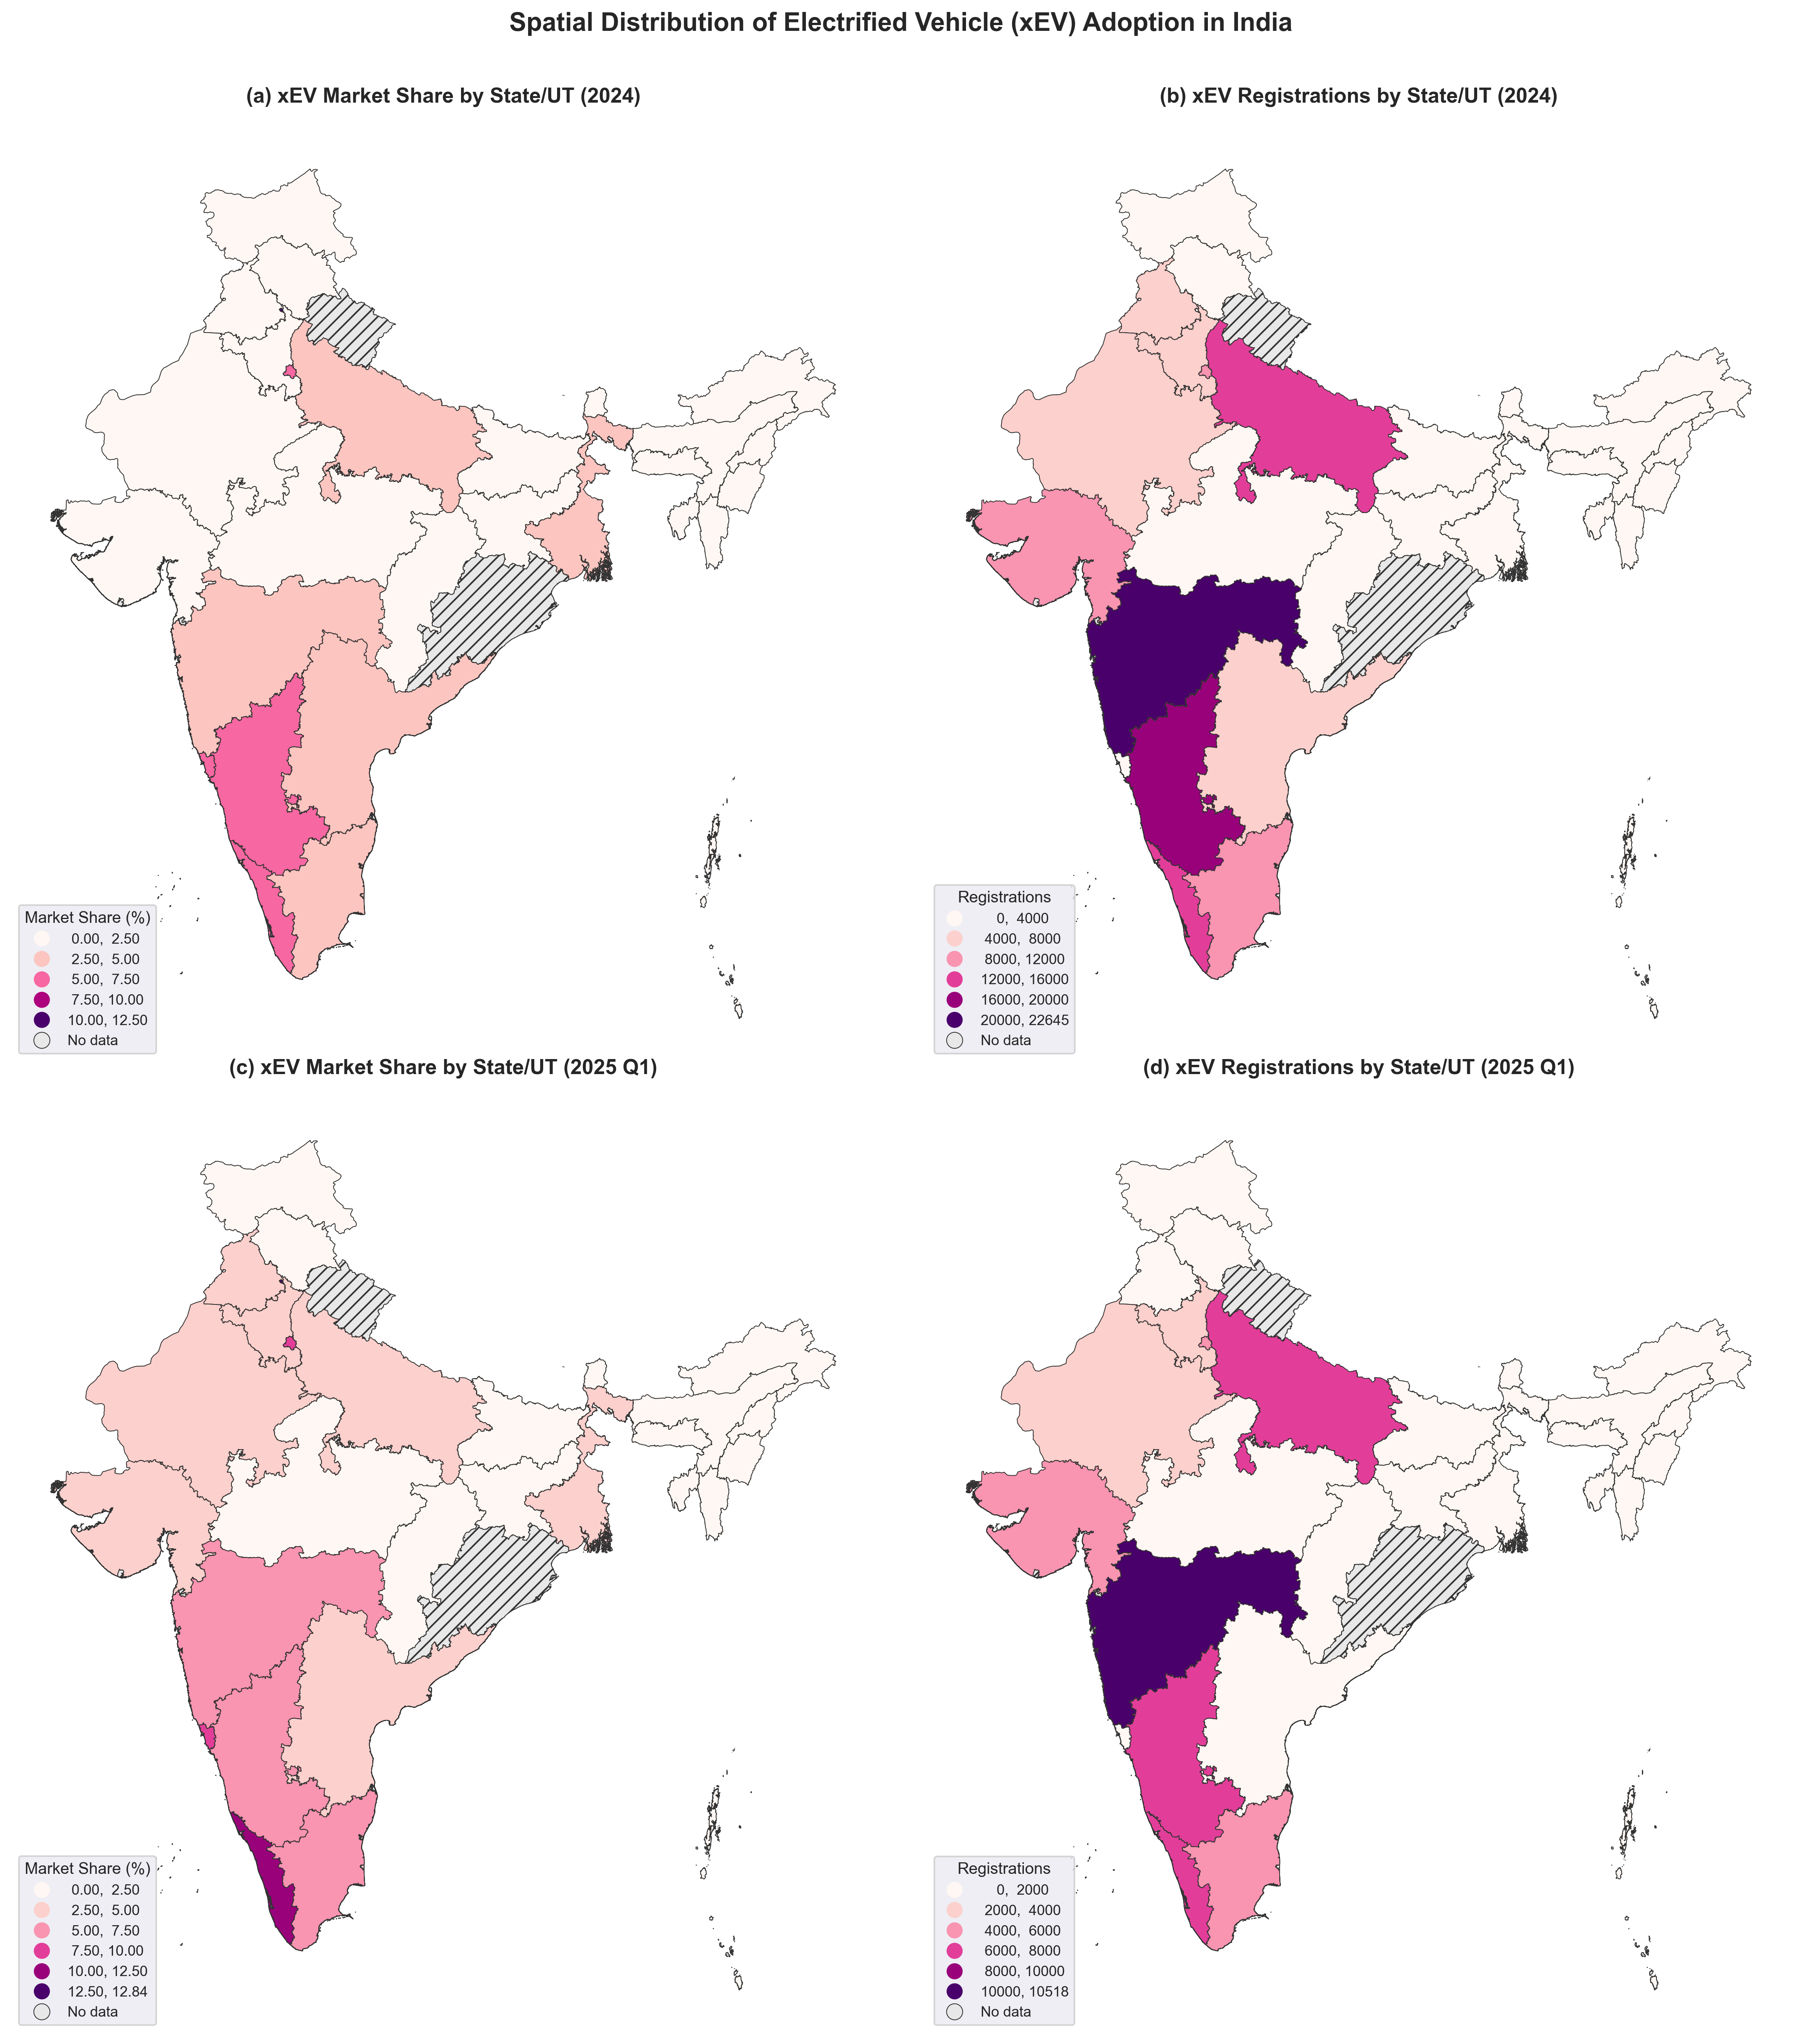

✓ Maps saved as PNG (300 DPI) and PDF (vector format)
✓ Color scheme: RdPu
✓ Market share bins: [2.5, 5.0, 7.5, 10.0, 12.5]
✓ Registration bins 2024: [4000, 8000, 12000, 16000, 20000]
✓ Registration bins 2025 Q1: [2000, 4000, 6000, 8000, 10000]


In [41]:
import matplotlib.pyplot as plt
import mapclassify
import matplotlib.patches as mpatches

# Define consistent color scheme and bins
COLOR_SCHEME = 'RdPu'  # Red-Purple, better for publications than BuPu
LINEWIDTH = 0.5
EDGECOLOR = '#333333'

# Define classification bins for consistency
BINS_MARKET_SHARE = [2.5, 5.0, 7.5, 10.0, 12.5]
BINS_REGISTRATIONS_2024 = [4000, 8000, 12000, 16000, 20000]
BINS_REGISTRATIONS_2025 = [2000, 4000, 6000, 8000, 10000]

# Create figure with publication-quality DPI
fig, axes = plt.subplots(2, 2, figsize=(16, 18), dpi=300)
fig.patch.set_facecolor('white')

# Flatten axes for easier iteration
ax_flat = axes.flatten()

# Common plotting parameters
missing_kwds = {
    'color': '#E8E8E8',
    'edgecolor': EDGECOLOR,
    'linewidth': LINEWIDTH,
    'hatch': '///',
    'label': 'No data'
}

# ===== SUBPLOT 1: 2024 Market Share (%) =====
merged_gdf_2024_pct.plot(
    column='EV + Hybrid',
    cmap=COLOR_SCHEME,
    linewidth=LINEWIDTH,
    ax=axes[0, 0],
    edgecolor=EDGECOLOR,
    legend=True,
    scheme='user_defined',
    classification_kwds={'bins': BINS_MARKET_SHARE},
    legend_kwds={
        'loc': 'lower left',
        'frameon': True,
        'fontsize': 9,
        'title': 'Market Share (%)',
        'title_fontsize': 10
    },
    missing_kwds=missing_kwds
)

axes[0, 0].set_title('(a) xEV Market Share by State/UT (2024)', 
                      fontsize=13, fontweight='bold', pad=15)
axes[0, 0].axis('off')

# ===== SUBPLOT 2: 2024 Registrations =====
merged_gdf_2024.plot(
    column='EV + Hybrid',
    cmap=COLOR_SCHEME,
    linewidth=LINEWIDTH,
    ax=axes[0, 1],
    edgecolor=EDGECOLOR,
    legend=True,
    scheme='user_defined',
    classification_kwds={'bins': BINS_REGISTRATIONS_2024},
    legend_kwds={
        'loc': 'lower left',
        'frameon': True,
        'fontsize': 9,
        'title': 'Registrations',
        'title_fontsize': 10,
        'fmt': '{:.0f}'
    },
    missing_kwds=missing_kwds
)

axes[0, 1].set_title('(b) xEV Registrations by State/UT (2024)', 
                      fontsize=13, fontweight='bold', pad=15)
axes[0, 1].axis('off')

# ===== SUBPLOT 3: 2025 Q1 Market Share (%) =====
merged_gdf_2025_pct.plot(
    column='EV + Hybrid',
    cmap=COLOR_SCHEME,
    linewidth=LINEWIDTH,
    ax=axes[1, 0],
    edgecolor=EDGECOLOR,
    legend=True,
    scheme='user_defined',
    classification_kwds={'bins': BINS_MARKET_SHARE},
    legend_kwds={
        'loc': 'lower left',
        'frameon': True,
        'fontsize': 9,
        'title': 'Market Share (%)',
        'title_fontsize': 10
    },
    missing_kwds=missing_kwds
)

axes[1, 0].set_title('(c) xEV Market Share by State/UT (2025 Q1)', 
                      fontsize=13, fontweight='bold', pad=15)
axes[1, 0].axis('off')

# ===== SUBPLOT 4: 2025 Q1 Registrations =====
merged_gdf_2025.plot(
    column='EV + Hybrid',
    cmap=COLOR_SCHEME,
    linewidth=LINEWIDTH,
    ax=axes[1, 1],
    edgecolor=EDGECOLOR,
    legend=True,
    scheme='user_defined',
    classification_kwds={'bins': BINS_REGISTRATIONS_2025},
    legend_kwds={
        'loc': 'lower left',
        'frameon': True,
        'fontsize': 9,
        'title': 'Registrations',
        'title_fontsize': 10,
        'fmt': '{:.0f}'
    },
    missing_kwds=missing_kwds
)

axes[1, 1].set_title('(d) xEV Registrations by State/UT (2025 Q1)', 
                      fontsize=13, fontweight='bold', pad=15)
axes[1, 1].axis('off')

# Add overall figure title
fig.suptitle('Spatial Distribution of Electrified Vehicle (xEV) Adoption in India', 
             fontsize=16, fontweight='bold', y=0.98)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save with high quality
plt.savefig('xev_choropleth_maps_2024_2025.png', 
            dpi=300, 
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none',
            pad_inches=0.1)

plt.savefig('xev_choropleth_maps_2024_2025.pdf', 
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none',
            pad_inches=0.1)

plt.show()

print("✓ Maps saved as PNG (300 DPI) and PDF (vector format)")
print(f"✓ Color scheme: {COLOR_SCHEME}")
print(f"✓ Market share bins: {BINS_MARKET_SHARE}")
print(f"✓ Registration bins 2024: {BINS_REGISTRATIONS_2024}")
print(f"✓ Registration bins 2025 Q1: {BINS_REGISTRATIONS_2025}")


RECOMMENDED APPROACH: Choose based on your research focus

1. MARKET SHARE COMPARISON (2 maps)
   → Best for: Showing adoption rate changes over time


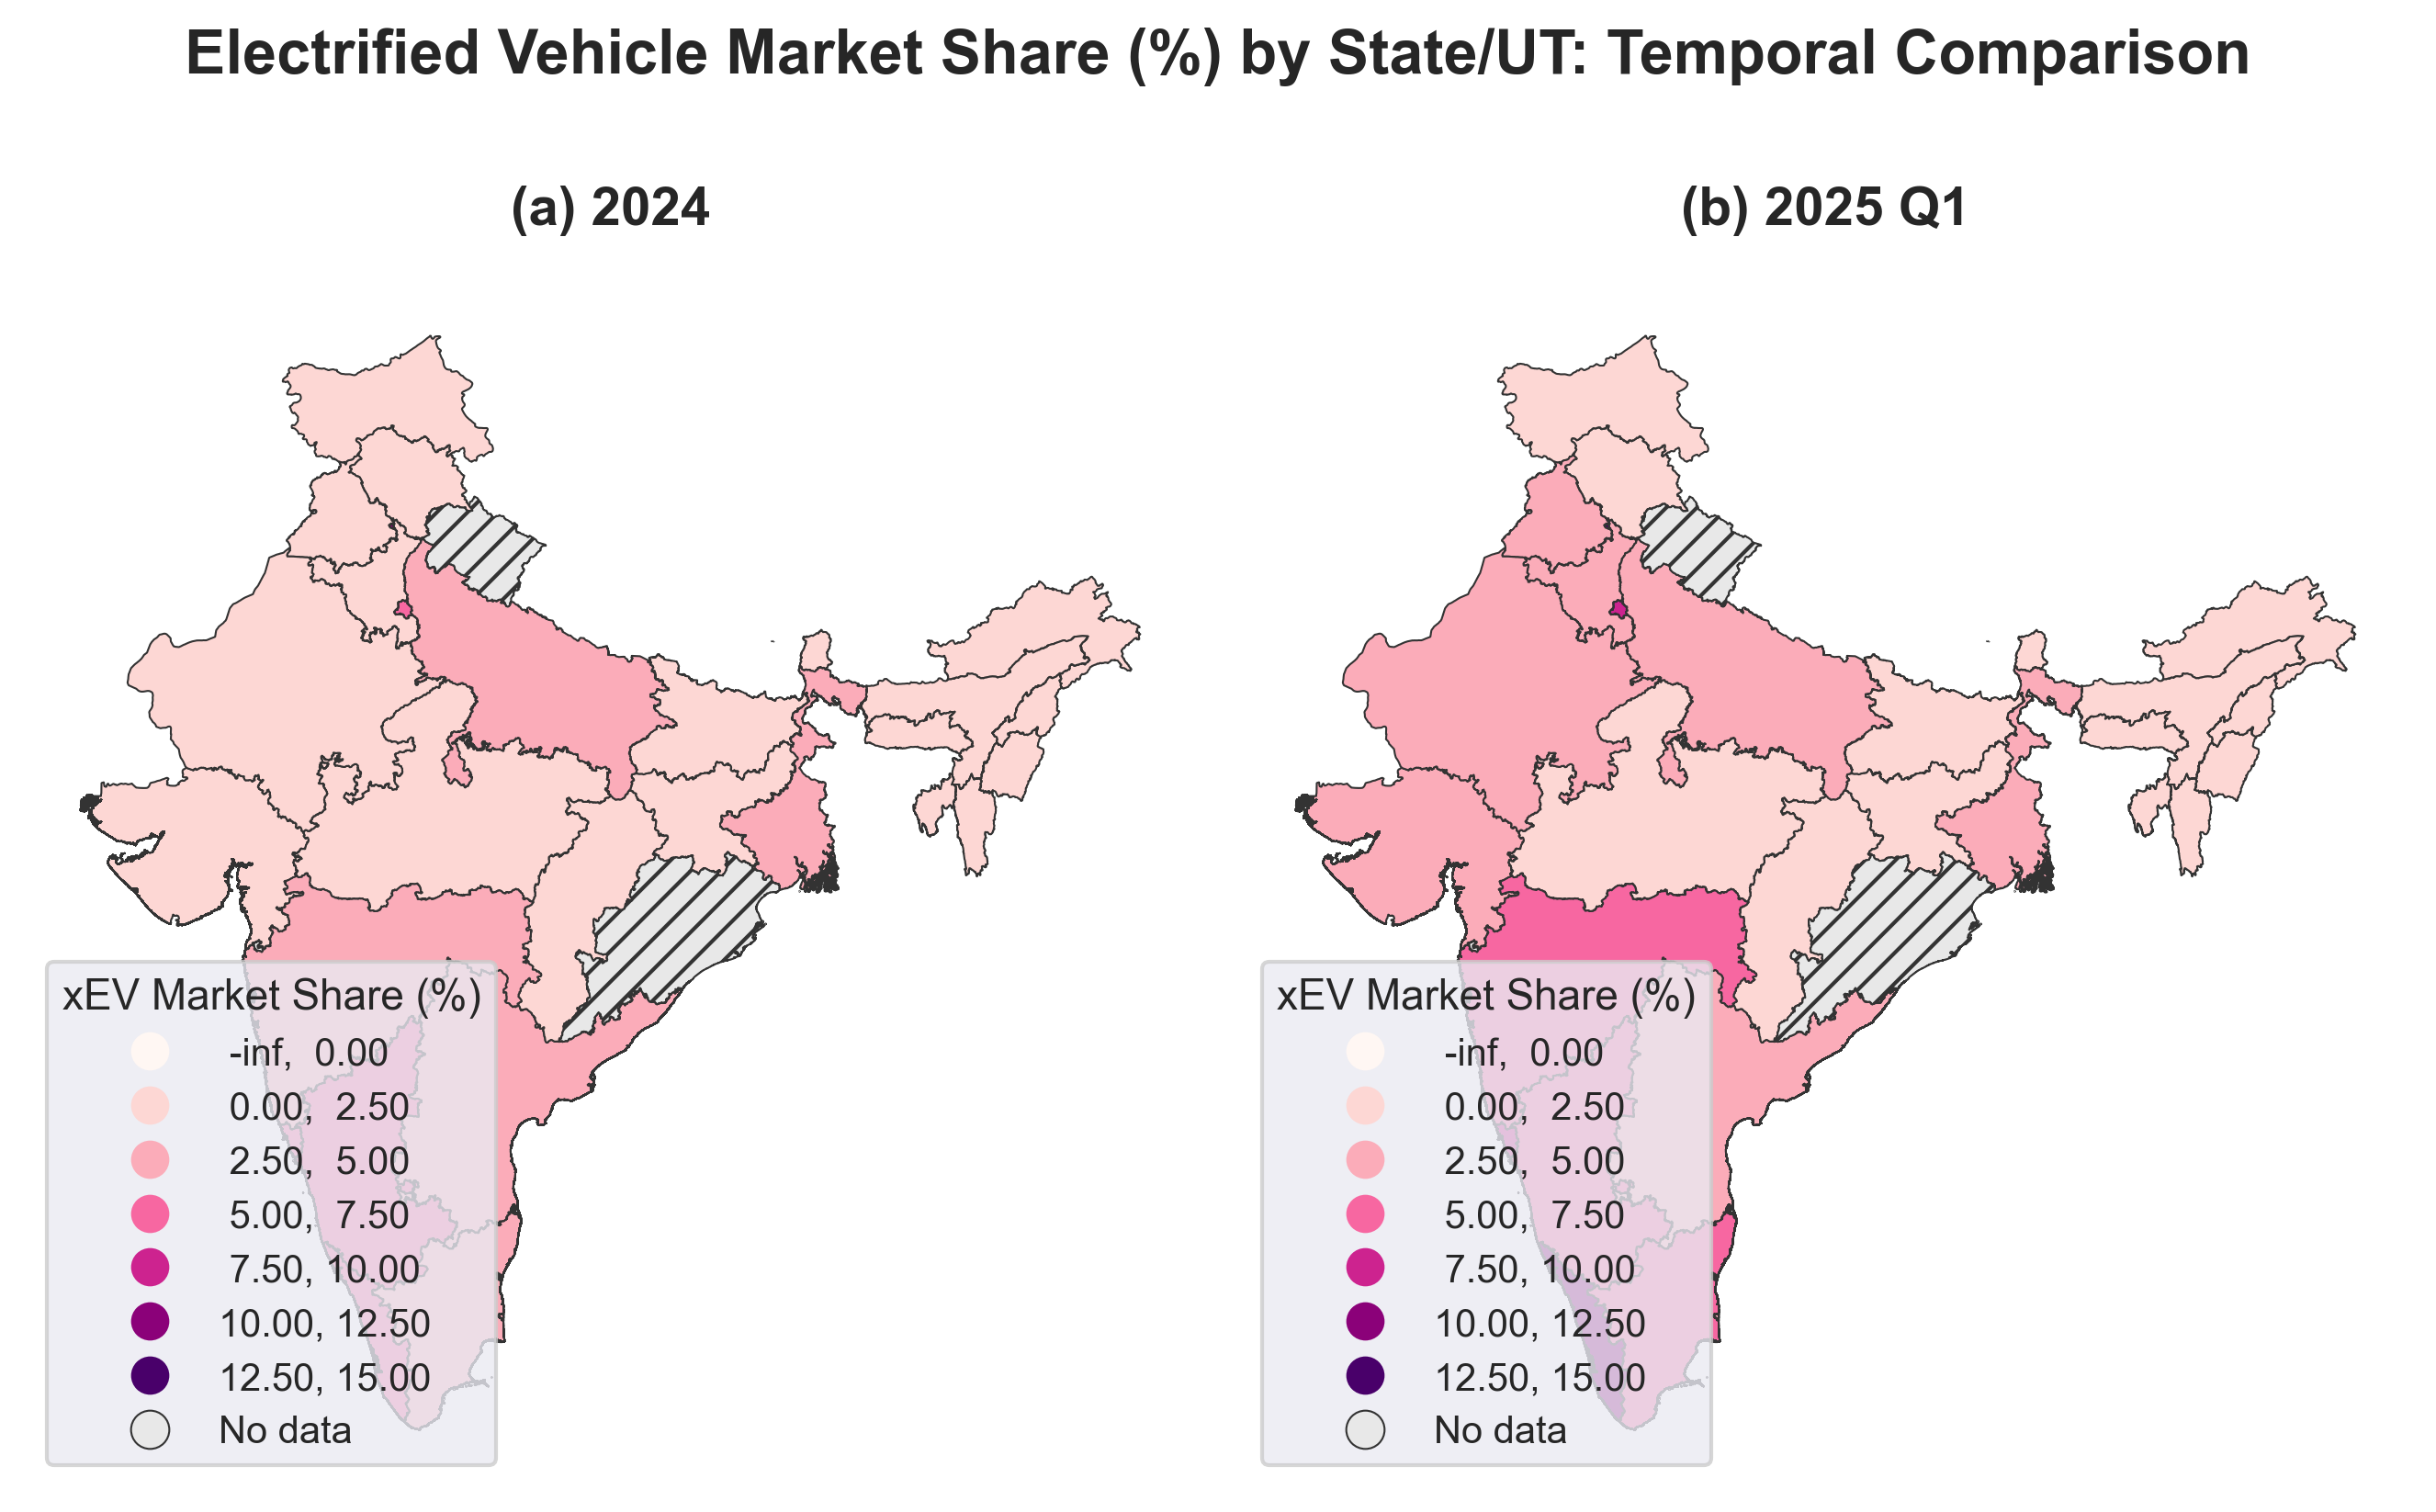

✓ Market Share (%) comparison saved

2. GROWTH MAP (1 map - RECOMMENDED!)
   → Best for: Highlighting which states are accelerating/decelerating


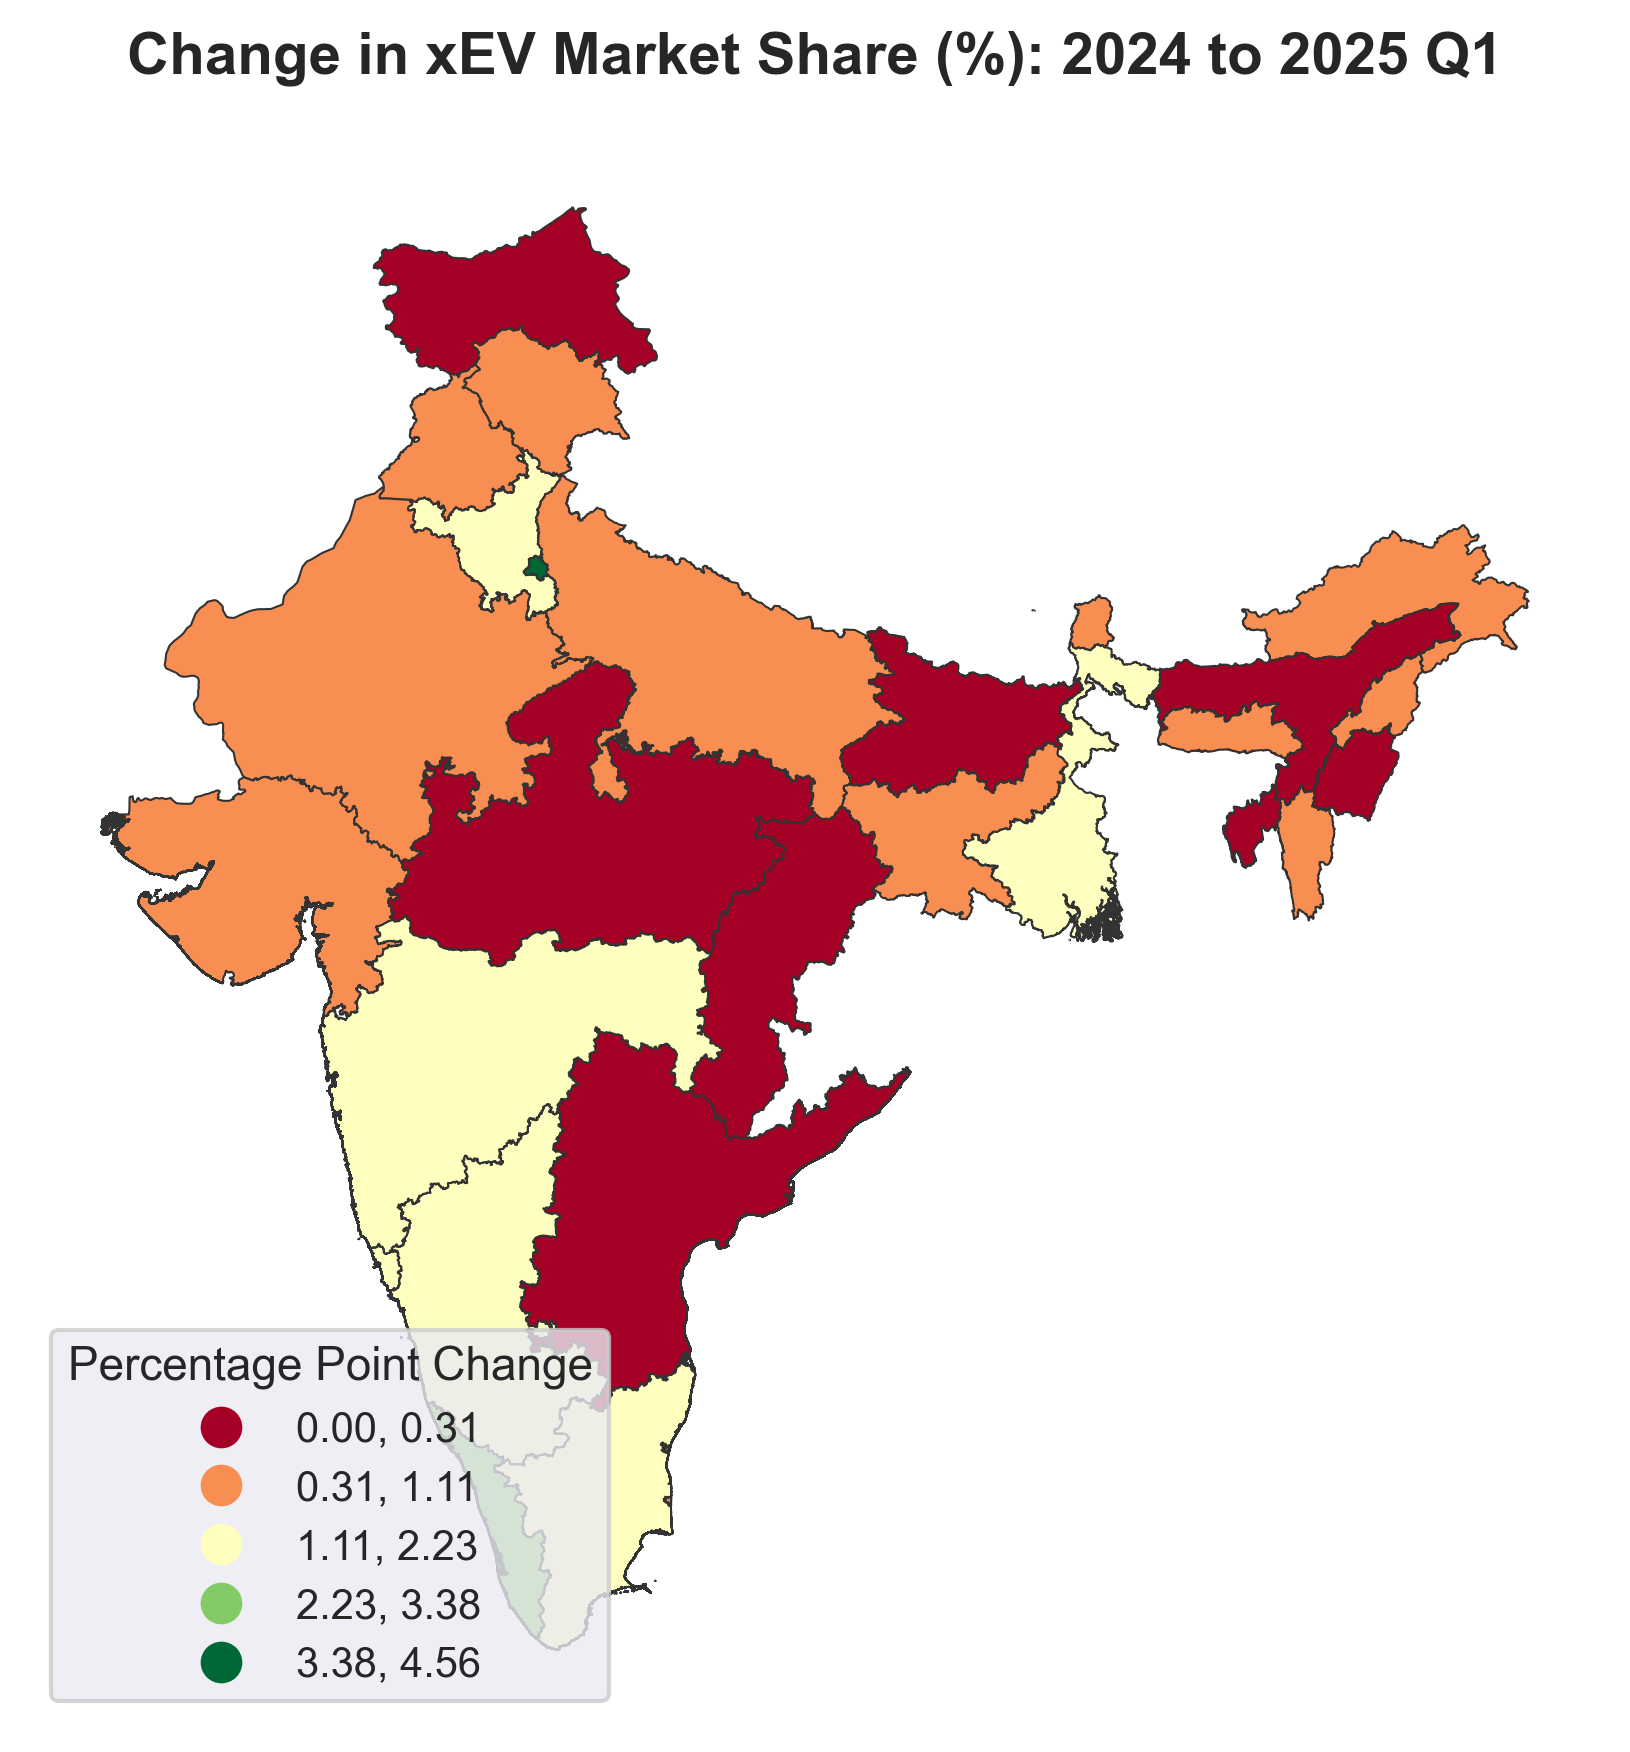

✓ Growth map saved - shows states with highest increase/decrease

3. COMBINED VIEW - LATEST PERIOD (2 maps)
   → Best for: Showing current state with penetration vs. volume


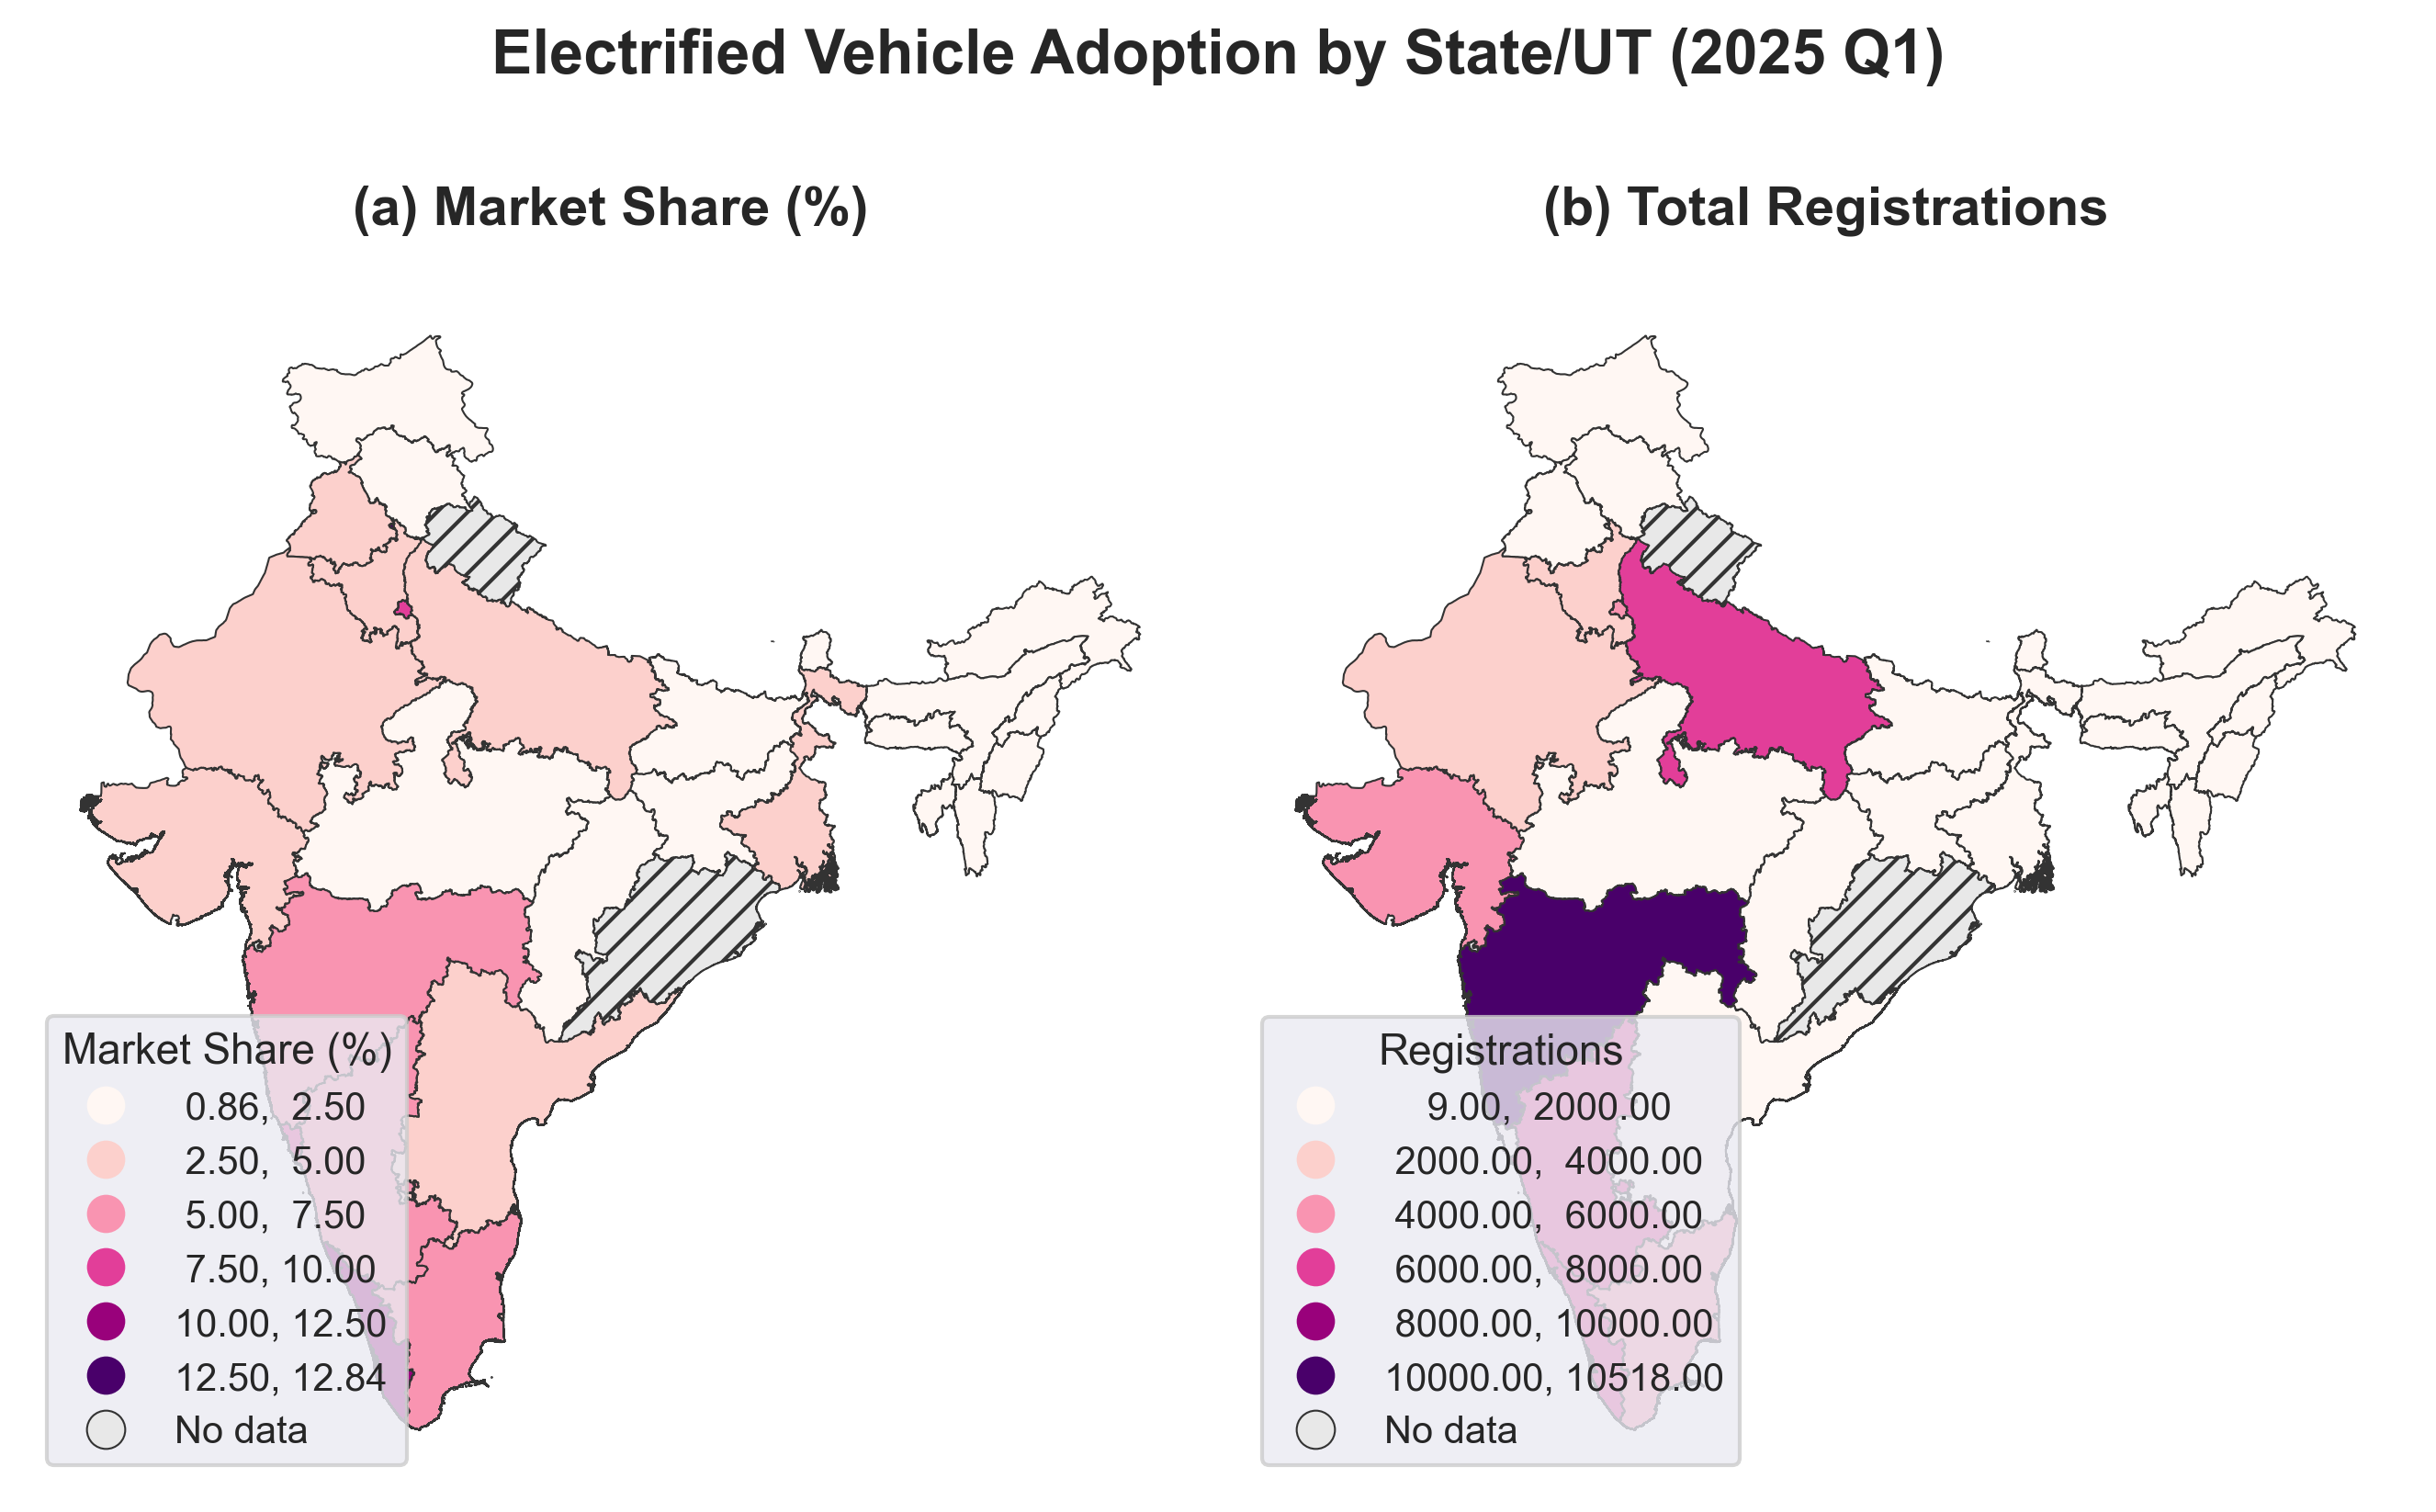

✓ Combined view for 2025 Q1 saved

RECOMMENDATION: Use Option 2 (Growth Map) + Option 3 (2025 Combined)
This gives you 3 total maps instead of 4, with better insights!


In [ ]:
import matplotlib.pyplot as plt
import mapclassify
import numpy as np

# OPTION 1: Side-by-side temporal comparison (RECOMMENDED)
# Shows change over time for ONE metric at a time - easiest to interpret

states_not_to_include = ['Andaman and Nicobar', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Lakshadweep']

def create_temporal_comparison(metric='market_share'):
    """
    Create side-by-side comparison of 2024 vs 2025 Q1
    metric: 'market_share' or 'registrations'
    """
    
    if metric == 'market_share':
        gdf_2024 = merged_gdf_2024_pct[~merged_gdf_2024_pct['STATE_GEO'].isin(states_not_to_include)].copy()
        gdf_2025 = merged_gdf_2025_pct[~merged_gdf_2025_pct['STATE_GEO'].isin(states_not_to_include)].copy()
        bins = [0, 2.5, 5.0, 7.5, 10.0, 12.5,15]
        title_suffix = 'Market Share (%)'
        cbar_label = 'xEV Market Share (%)'
        filename = 'xev_market_share_comparison'
    else:
        gdf_2024 = merged_gdf_2024[~merged_gdf_2024['STATE_GEO'].isin(states_not_to_include)].copy()
        gdf_2025 = merged_gdf_2025[~merged_gdf_2025['STATE_GEO'].isin(states_not_to_include)].copy()
        bins = [2000, 4000, 6000, 8000, 12000, 16000, 20000, 24000]
        title_suffix = 'Registrations'
        cbar_label = 'xEV Registrations (count)'
        filename = 'xev_registrations_comparison'
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(9, 6), dpi=300)
    fig.patch.set_facecolor('white')
    
    COLOR_SCHEME = 'RdPu'
    LINEWIDTH = 0.5
    EDGECOLOR = '#333333'
    
    missing_kwds = {
        'color': '#E8E8E8',
        'edgecolor': EDGECOLOR,
        'linewidth': LINEWIDTH,
        'hatch': '///',
        'label': 'No data'
    }
    
    # Plot 2024
    gdf_2024.plot(
        column='EV + Hybrid',
        cmap=COLOR_SCHEME,
        linewidth=LINEWIDTH,
        ax=axes[0],
        edgecolor=EDGECOLOR,
        legend=True,
        scheme='user_defined',
        classification_kwds={'bins': bins},
        legend_kwds={
            'loc': 'lower left',
            'frameon': True,
            'fontsize': 10,
            'title': cbar_label,
            'title_fontsize': 11
        },
        missing_kwds=missing_kwds
    )
    axes[0].set_title(f'(a) 2024', fontsize=14, fontweight='bold', pad=15)
    axes[0].axis('off')
    
    # Plot 2025 Q1
    gdf_2025.plot(
        column='EV + Hybrid',
        cmap=COLOR_SCHEME,
        linewidth=LINEWIDTH,
        ax=axes[1],
        edgecolor=EDGECOLOR,
        legend=True,
        scheme='user_defined',
        classification_kwds={'bins': bins},
        legend_kwds={
            'loc': 'lower left',
            'frameon': True,
            'fontsize': 10,
            'title': cbar_label,
            'title_fontsize': 11
        },
        missing_kwds=missing_kwds
    )
    axes[1].set_title(f'(b) 2025 Q1', fontsize=14, fontweight='bold', pad=15)
    axes[1].axis('off')
    
    # Overall title
    fig.suptitle(f'Electrified Vehicle {title_suffix} by State/UT: Temporal Comparison', 
                 fontsize=16, fontweight='bold', y=0.95)
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(f'{filename}.png', dpi=300, bbox_inches='tight', 
                facecolor='white', pad_inches=0.1)
    plt.savefig(f'{filename}.pdf', bbox_inches='tight', 
                facecolor='white', pad_inches=0.1)
    plt.show()
    
    print(f"✓ {title_suffix} comparison saved")


# OPTION 2: Growth/Change Map (MOST INSIGHTFUL)
# Shows the actual change between periods - tells the story better!

def create_growth_map(metric='market_share'):
    """
    Create a single map showing growth from 2024 to 2025 Q1
    This is often MORE informative than showing both periods
    """
    
    if metric == 'market_share':
        gdf_2024 = merged_gdf_2024_pct[~merged_gdf_2024_pct['STATE_GEO'].isin(states_not_to_include)].copy()
        gdf_2025 = merged_gdf_2025_pct[~merged_gdf_2025_pct['STATE_GEO'].isin(states_not_to_include)].copy()
        title_text = 'Change in xEV Market Share (%): 2024 to 2025 Q1'
        cbar_label = 'Percentage Point Change'
        filename = 'xev_market_share_growth'
    else:
        gdf_2024 = merged_gdf_2024[~merged_gdf_2024['STATE_GEO'].isin(states_not_to_include)].copy()
        gdf_2025 = merged_gdf_2025[~merged_gdf_2025['STATE_GEO'].isin(states_not_to_include)].copy()
        title_text = 'Change in xEV Registrations: 2024 to 2025 Q1'
        cbar_label = 'Registration Change (count)'
        filename = 'xev_registrations_growth'
    
    # Calculate change
    gdf_change = gdf_2025.copy()
    gdf_change['Change'] = gdf_2025['EV + Hybrid'] - gdf_2024['EV + Hybrid']
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(9, 6), dpi=300)
    fig.patch.set_facecolor('white')
    
    LINEWIDTH = 0.5
    EDGECOLOR = '#333333'
    
    # Use diverging colormap (shows increase/decrease)
    gdf_change.plot(
        column='Change',
        cmap='RdYlGn',  # Red (decrease) to Green (increase)
        linewidth=LINEWIDTH,
        ax=ax,
        edgecolor=EDGECOLOR,
        legend=True,
        scheme='natural_breaks',  # Automatically finds natural breaks
        legend_kwds={
            'loc': 'lower left',
            'frameon': True,
            'fontsize': 10,
            'title': cbar_label,
            'title_fontsize': 11
        }
    )
    
    ax.set_title(title_text, fontsize=14, fontweight='bold', pad=15)
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'{filename}.png', dpi=300, bbox_inches='tight', 
                facecolor='white', pad_inches=0.1)
    plt.savefig(f'{filename}.pdf', bbox_inches='tight', 
                facecolor='white', pad_inches=0.1)
    plt.show()
    
    print(f"✓ Growth map saved - shows states with highest increase/decrease")


# OPTION 3: Combined metric with small multiples (COMPACT)
# Shows both metrics in a compact 2-panel layout

def create_combined_view(year='2024'):
    """
    Show both market share AND registrations for ONE time period
    Easier to see relationship between penetration and volume
    """
    
    if year == '2024':
        gdf_pct = merged_gdf_2024_pct[~merged_gdf_2024_pct['STATE_GEO'].isin(states_not_to_include)].copy()
        gdf_abs = merged_gdf_2024[~merged_gdf_2024['STATE_GEO'].isin(states_not_to_include)].copy()
        bins_reg = [4000, 8000, 12000, 16000, 20000]
        year_label = '2024'
    else:
        gdf_pct = merged_gdf_2025_pct[~merged_gdf_2025_pct['STATE_GEO'].isin(states_not_to_include)].copy()
        gdf_abs = merged_gdf_2025[~merged_gdf_2025['STATE_GEO'].isin(states_not_to_include)].copy()
        bins_reg = [2000, 4000, 6000, 8000, 10000]
        year_label = '2025 Q1'
    
    fig, axes = plt.subplots(1, 2, figsize=(9, 6), dpi=300)
    fig.patch.set_facecolor('white')
    
    COLOR_SCHEME = 'RdPu'
    LINEWIDTH = 0.5
    EDGECOLOR = '#333333'
    bins_pct = [2.5, 5.0, 7.5, 10.0, 12.5]
    
    missing_kwds = {
        'color': '#E8E8E8',
        'edgecolor': EDGECOLOR,
        'linewidth': LINEWIDTH,
        'hatch': '///',
        'label': 'No data'
    }
    
    # Market Share
    gdf_pct.plot(
        column='EV + Hybrid',
        cmap=COLOR_SCHEME,
        linewidth=LINEWIDTH,
        ax=axes[0],
        edgecolor=EDGECOLOR,
        legend=True,
        scheme='user_defined',
        classification_kwds={'bins': bins_pct},
        legend_kwds={
            'loc': 'lower left',
            'frameon': True,
            'fontsize': 10,
            'title': 'Market Share (%)',
            'title_fontsize': 11
        },
        missing_kwds=missing_kwds
    )
    axes[0].set_title('(a) Market Share (%)', fontsize=14, fontweight='bold', pad=15)
    axes[0].axis('off')
    
    # Registrations
    gdf_abs.plot(
        column='EV + Hybrid',
        cmap=COLOR_SCHEME,
        linewidth=LINEWIDTH,
        ax=axes[1],
        edgecolor=EDGECOLOR,
        legend=True,
        scheme='user_defined',
        classification_kwds={'bins': bins_reg},
        legend_kwds={
            'loc': 'lower left',
            'frameon': True,
            'fontsize': 10,
            'title': 'Registrations',
            'title_fontsize': 11
        },
        missing_kwds=missing_kwds
    )
    axes[1].set_title('(b) Total Registrations', fontsize=14, fontweight='bold', pad=15)
    axes[1].axis('off')
    
    fig.suptitle(f'Electrified Vehicle Adoption by State/UT ({year_label})', 
                 fontsize=16, fontweight='bold', y=0.95)
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(f'xev_combined_view_{year}.png', dpi=300, bbox_inches='tight', 
                facecolor='white', pad_inches=0.1)
    plt.savefig(f'xev_combined_view_{year}.pdf', bbox_inches='tight', 
                facecolor='white', pad_inches=0.1)
    plt.show()
    
    print(f"✓ Combined view for {year_label} saved")


# ==============================================================================
# USAGE EXAMPLES - Choose the best option for your research story
# ==============================================================================

print("=" * 70)
print("RECOMMENDED APPROACH: Choose based on your research focus")
print("=" * 70)

# Use Case 1: Focus on temporal change in market penetration
print("\n1. MARKET SHARE COMPARISON (2 maps)")
print("   → Best for: Showing adoption rate changes over time")
create_temporal_comparison(metric='market_share')

# Use Case 2: Focus on growth/change (MOST INSIGHTFUL!)
print("\n2. GROWTH MAP (1 map - RECOMMENDED!)")
print("   → Best for: Highlighting which states are accelerating/decelerating")
create_growth_map(metric='market_share')

# Use Case 3: Focus on one time period with both metrics
print("\n3. COMBINED VIEW - LATEST PERIOD (2 maps)")
print("   → Best for: Showing current state with penetration vs. volume")
create_combined_view(year='2025')

print("\n" + "=" * 70)
print("RECOMMENDATION: Use Option 2 (Growth Map) + Option 3 (2025 Combined)")
print("This gives you 3 total maps instead of 4, with better insights!")
print("=" * 70)

In [ ]:
'''import matplotlib.pyplot as plt
import mapclassify
import numpy as np

# IMPROVED Growth/Change Map with Better Legend Formatting
states_not_to_include = ['Andaman and Nicobar', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Lakshadweep']
def create_growth_map(metric='market_share', start_year='2020', end_year='2025'):
    """
    Create a single map showing growth with properly formatted legend
    """
    
    if metric == 'market_share':
        if start_year == '2020':
            gdf_start = merged_gdf_2020_pct[~merged_gdf_2020_pct['STATE_GEO'].isin(states_not_to_include)].copy()
        else:
            gdf_start = merged_gdf_2024_pct[~merged_gdf_2024_pct['STATE_GEO'].isin(states_not_to_include)].copy()
        
        gdf_end = merged_gdf_2025_pct[~merged_gdf_2025_pct['STATE_GEO'].isin(states_not_to_include)].copy()
        title_text = f'Change in xEV Market Share: {start_year} to {end_year} Q1'
        cbar_label = 'Percentage Point Change'
        filename = f'xev_market_share_growth_{start_year}_to_{end_year}'
        
        # Define meaningful bins for percentage point change
        bins = [-1, 0, 2, 4, 6, 10, 15]  # Adjust based on your data range
        
    else:
        if start_year == '2020':
            gdf_start = merged_gdf_2020[~merged_gdf_2020['STATE_GEO'].isin(states_not_to_include)].copy()
        else:
            gdf_start = merged_gdf_2024[~merged_gdf_2024['STATE_GEO'].isin(states_not_to_include)].copy()
        
        gdf_end = merged_gdf_2025.copy()
        title_text = f'Change in xEV Registrations: {start_year} to {end_year} Q1'
        cbar_label = 'Registration Change'
        filename = f'xev_registrations_growth_{start_year}_to_{end_year}'
        
        # Define bins for registration change
        bins = [-5000, 0, 2000, 5000, 10000, 15000, 20000]
    
    # Calculate change
    gdf_change = gdf_end.copy()
    gdf_change['Change'] = gdf_end['EV + Hybrid'] - gdf_start['EV + Hybrid']

    
    # Print statistics for debugging
    print(f"\n{metric.upper()} - Change Statistics ({start_year} to {end_year}):")
    print(f"  Min change: {gdf_change['Change'].min():.2f}")
    print(f"  Max change: {gdf_change['Change'].max():.2f}")
    print(f"  Mean change: {gdf_change['Change'].mean():.2f}")
    print(f"  Median change: {gdf_change['Change'].median():.2f}")
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(10, 12), dpi=300)
    fig.patch.set_facecolor('white')
    
    LINEWIDTH = 0.5
    EDGECOLOR = '#333333'
    
    # Determine if we need to adjust bins based on actual data
    actual_min = gdf_change['Change'].min()
    actual_max = gdf_change['Change'].max()
    
    # Auto-adjust bins for better coverage
    if metric == 'market_share':
        if actual_min < -1:
            bins = [actual_min, -2, 0, 2, 4, 6, 8, 10, actual_max]
        else:
            bins = [0, 2, 4, 6, 8, 10, actual_max]
    
    # Plot with user-defined bins
    gdf_change.plot(
        column='Change',
        cmap='YlGn',  
        linewidth=LINEWIDTH,
        ax=ax,
        edgecolor=EDGECOLOR,
        legend=True,
        scheme='natural_breaks',#'user_defined',  # Use defined bins instead of natural_breaks
        classification_kwds={'bins': bins},
        legend_kwds={
            'loc': 'lower left',
            'frameon': True,
            'fontsize': 9,
            'title': cbar_label,
            'title_fontsize': 10,
            'fmt': '{:.1f}'  # Format to 1 decimal place
        },
        missing_kwds={
            'color': '#E8E8E8',
            'edgecolor': EDGECOLOR,
            'linewidth': LINEWIDTH,
            'label': 'No data'
        }
    )
    
    ax.set_title(title_text, fontsize=13, fontweight='bold', pad=15)
    ax.axis('off')
    
    # Add text annotation for interpretation
    if metric == 'market_share':
        note_text = 'Note: Positive values indicate increased xEV adoption'
        ax.text(0.02, 0.02, note_text, transform=ax.transAxes,
                fontsize=8, style='italic', bbox=dict(boxstyle='round',
                facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.savefig(f'{filename}.png', dpi=300, bbox_inches='tight', 
                facecolor='white', pad_inches=0.1)
    plt.savefig(f'{filename}.pdf', bbox_inches='tight', 
                facecolor='white', pad_inches=0.1)
    plt.show()
    
    print(f"✓ Growth map saved: {filename}")
    print(f"  Bins used: {bins}\n")


#### Method 2 here
'''
# Alternative: Create a cleaner version with quantile-based classification
'''
def create_growth_map_quantile(metric='market_share', start_year='2020', end_year='2025'):
    """
    Create growth map using quantiles for more balanced color distribution
    """
    
    if metric == 'market_share':
        if start_year == '2020':
            gdf_start = merged_gdf_2020_pct[~merged_gdf_2020_pct['STATE_GEO'].isin(states_not_to_include)].copy()
        else:
            gdf_start = merged_gdf_2024_pct[~merged_gdf_2024_pct['STATE_GEO'].isin(states_not_to_include)].copy()
        
        gdf_end = merged_gdf_2025_pct[~merged_gdf_2025_pct['STATE_GEO'].isin(states_not_to_include)].copy()
        title_text = f'Change in xEV Market Share: {start_year} to {end_year} Q1'
        cbar_label = 'Market Share Δ (pp)'
        filename = f'xev_market_share_growth_{start_year}_to_{end_year}_quantile'
        
    else:
        if start_year == '2020':
            gdf_start = merged_gdf_2020[~merged_gdf_2020['STATE_GEO'].isin(states_not_to_include)].copy()
        else:
            gdf_start = merged_gdf_2024[~merged_gdf_2024['STATE_GEO'].isin(states_not_to_include)].copy()
        
        gdf_end = merged_gdf_2025[~merged_gdf_2025['STATE_GEO'].isin(states_not_to_include)].copy()
        title_text = f'Change in xEV Registrations: {start_year} to {end_year} Q1'
        cbar_label = 'Registration Δ'
        filename = f'xev_registrations_growth_{start_year}_to_{end_year}_quantile'
    
    # Calculate change
    gdf_change = gdf_end.copy()
    gdf_change['Change'] = gdf_end['EV + Hybrid'] - gdf_start['EV + Hybrid']

    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(10, 12), dpi=300)
    fig.patch.set_facecolor('white')
    
    LINEWIDTH = 0.5
    EDGECOLOR = '#333333'
    
    # Plot with quantiles (divides data into equal groups)
    gdf_change.plot(
        column='Change',
        cmap='YlGn',
        linewidth=LINEWIDTH,
        ax=ax,
        edgecolor=EDGECOLOR,
        legend=True,
        scheme='quantiles',  # Equal number of observations per class
        k=5,  # 5 classes
        legend_kwds={
            'loc': 'lower left',
            'frameon': True,
            'fontsize': 9,
            'title': cbar_label,
            'title_fontsize': 10,
            'fmt': '{:.1f}'
        },
        missing_kwds={
            'color': '#E8E8E8',
            'edgecolor': EDGECOLOR,
            'linewidth': LINEWIDTH,
            'label': 'No data'
        }
    )
    
    ax.set_title(title_text, fontsize=13, fontweight='bold', pad=15)
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'{filename}.png', dpi=300, bbox_inches='tight', 
                facecolor='white', pad_inches=0.1)
    plt.savefig(f'{filename}.pdf', bbox_inches='tight', 
                facecolor='white', pad_inches=0.1)
    plt.show()
    
    print(f"✓ Quantile-based growth map saved: {filename}\n")

'''
# ==============================================================================
# USAGE
# ==============================================================================
'''
print("=" * 70)
print("CREATING GROWTH MAPS WITH PROPER FORMATTING")
print("=" * 70)

# Method 1: User-defined bins (more control)
print("\nMethod 1: Custom bins (recommended for research papers)")
create_growth_map(metric='market_share', start_year='2020', end_year='2025')

# Method 2: Quantile-based (more balanced color distribution)
'''
'''
print("\nMethod 2: Quantile-based classification")
create_growth_map_quantile(metric='market_share', start_year='2020', end_year='2025')
'''
# Also create for registrations if needed
# create_growth_map(metric='registrations', start_year='2020', end_year='2025')
'''
print("=" * 70)
print("TIP: Method 1 uses meaningful thresholds (0, 2, 4, 6, 8, 10 pp)")

print("     Method 2 ensures each color class has equal number of states")
print("=" * 70)'''

'\nprint("=" * 70)\nprint("TIP: Method 1 uses meaningful thresholds (0, 2, 4, 6, 8, 10 pp)")\n\nprint("     Method 2 ensures each color class has equal number of states")\nprint("=" * 70)'